<a href="https://colab.research.google.com/github/luisferojedat/claimai-policy-analyzer/blob/main/c_lculo_y_optimizaci_n_en_inteligencia_artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo y Optimización en Inteligencia Artificial

**NOMBRE DEL ESTUDIANTE:** LUIS FERNANDO OJEDA TINOCO

**ASIGNATURA:** Cálculo y Optimización en IA  
**PLATAFORMA:** Google Colab

## Introducción

El presente cuaderno desarrolla la implementación del algoritmo de Descenso del Gradiente desde sus fundamentos y analiza su comportamiento en funciones polinomiales, trigonométricas, exponenciales y logarítmicas. Mediante diferentes puntos iniciales y tasas de aprendizaje, se estudia la convergencia del algoritmo, la localización de mínimos, la aparición de divergencias y la importancia del dominio de las funciones. Asimismo, se incorpora un análisis de sensibilidad y una aplicación práctica vinculada con la estimación preliminar de costos de reparación vehicular, con el propósito de relacionar la optimización matemática con un problema elemental de aprendizaje automático.

## Objetivo General del Cuaderno

El objetivo de este cuaderno es implementar el algoritmo de Descenso del Gradiente y aplicarlo a funciones polinomiales, trigonométricas, exponenciales y logarítmicas, analizando:

- La convergencia del algoritmo.
- El efecto de la tasa de aprendizaje.
- El efecto del punto inicial.
- La existencia de mínimos locales o globales.
- Las dificultades que aparecen en funciones no convexas o con dominio restringido.
- La relación del Descenso del Gradiente con la optimización utilizada en Inteligencia Artificial.

In [30]:
# Preparación automática del entorno para Jupyter Notebook
# Esta celda instala únicamente las librerías que no estén disponibles.

import sys
import subprocess
import importlib.util

dependencias = {
    "numpy": "numpy",
    "sympy": "sympy",
    "pandas": "pandas",
    "matplotlib": "matplotlib"
}

paquetes_faltantes = [
    paquete_pip
    for modulo, paquete_pip in dependencias.items()
    if importlib.util.find_spec(modulo) is None
]

if paquetes_faltantes:
    print("Instalando librerías faltantes:", ", ".join(paquetes_faltantes))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *paquetes_faltantes
    ])
    print("Instalación finalizada correctamente.")
else:
    print("Todas las librerías necesarias ya están instaladas.")

print("Entorno preparado. Ahora puede ejecutarse el resto del notebook.")

Todas las librerías necesarias ya están instaladas.
Entorno preparado. Ahora puede ejecutarse el resto del notebook.


## 1. Librerías y Configuración General

Importamos las librerías necesarias para la implementación del algoritmo, el cálculo simbólico de funciones y derivadas, la manipulación de datos y la visualización. Además, se establece una configuración base para Matplotlib para asegurar una presentación coherente de los gráficos.

In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# Configuración general para Matplotlib
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'

## 2. Implementación del Algoritmo de Descenso del Gradiente

Definimos la función `gradient_descent` que implementa el algoritmo desde cero.

In [2]:
import numpy as np
def gradient_descent(
    funcion,
    derivada,
    x_start,
    lr,
    max_iters,
    tol=1e-8,
    domain_check=None,
    max_abs_x=1e6
):
    x_actual = float(x_start)

    if domain_check is not None and not domain_check(x_actual):
        return {
            "trayectoria_x": np.array([]),
            "trayectoria_y": np.array([]),
            "x_final": np.nan,
            "y_final": np.nan,
            "iteraciones": 0,
            "estado": "Límite del dominio alcanzado"
        }

    y_actual = funcion(x_actual)
    trayectoria_x = [x_actual]
    trayectoria_y = [y_actual]

    for i in range(1, max_iters + 1):
        gradiente = derivada(x_actual)

        if not np.isfinite(gradiente):
            return {
                "trayectoria_x": np.array(trayectoria_x),
                "trayectoria_y": np.array(trayectoria_y),
                "x_final": x_actual,
                "y_final": y_actual,
                "iteraciones": i - 1,
                "estado": "Divergencia detectada"
            }

        x_nuevo = x_actual - lr * gradiente

        if not np.isfinite(x_nuevo) or abs(x_nuevo) > max_abs_x:
            return {
                "trayectoria_x": np.array(trayectoria_x),
                "trayectoria_y": np.array(trayectoria_y),
                "x_final": x_actual,
                "y_final": y_actual,
                "iteraciones": i - 1,
                "estado": "Divergencia detectada"
            }

        if domain_check is not None and not domain_check(x_nuevo):
            return {
                "trayectoria_x": np.array(trayectoria_x),
                "trayectoria_y": np.array(trayectoria_y),
                "x_final": x_actual,
                "y_final": y_actual,
                "iteraciones": i - 1,
                "estado": "Límite del dominio alcanzado"
            }

        y_nuevo = funcion(x_nuevo)

        if not np.isfinite(y_nuevo):
            return {
                "trayectoria_x": np.array(trayectoria_x),
                "trayectoria_y": np.array(trayectoria_y),
                "x_final": x_actual,
                "y_final": y_actual,
                "iteraciones": i - 1,
                "estado": "Divergencia detectada"
            }

        trayectoria_x.append(x_nuevo)
        trayectoria_y.append(y_nuevo)

        if abs(x_nuevo - x_actual) < tol:
            return {
                "trayectoria_x": np.array(trayectoria_x),
                "trayectoria_y": np.array(trayectoria_y),
                "x_final": x_nuevo,
                "y_final": y_nuevo,
                "iteraciones": i,
                "estado": "Convergencia alcanzada"
            }

        x_actual = x_nuevo
        y_actual = y_nuevo

    return {
        "trayectoria_x": np.array(trayectoria_x),
        "trayectoria_y": np.array(trayectoria_y),
        "x_final": x_actual,
        "y_final": y_actual,
        "iteraciones": max_iters,
        "estado": "Máximo de iteraciones alcanzado"
    }

## EJERCICIO 1: Funciones Polinomiales y Trigonométricas

**Instrucciones del Ejercicio 1:**

1.  **Implementación del Algoritmo:** Ya se definió la función `gradient_descent`.
2.  **Aplicación del Algoritmo:** Aplicar a cada función con diferentes puntos iniciales y tasas de aprendizaje, documentando los mínimos.
3.  **Visualización del Algoritmo:** Graficar cada función y el camino seguido por el Descenso del Gradiente.

## Ejercicio 1. Implementación

A continuación se presentan las funciones polinomiales y trigonométricas a analizar, junto con sus derivadas:

**Función a:** `g_a(x) = x^3 + 3x^2 - 2`
**Derivada:** `g_a'(x) = 3x^2 + 6x`

**Función b:** `g_b(x) = x^2 sin(x) + x`
**Derivada:** `g_b'(x) = 2x sin(x) + x^2 cos(x) + 1`

**Función c:** `g_c(x) = 4x^2 - 10x + 4`
**Derivada:** `g_c'(x) = 8x - 10`

**Función d:** `g_d(x) = x^4 - 4x^3 + 4`
**Derivada:** `g_d'(x) = 4x^3 - 12x^2`

In [3]:
# Definición de todas las funciones y sus derivadas para el Ejercicio 1
x_sym = sp.Symbol('x')

# Función a
g_a_sym = x_sym**3 + 3*x_sym**2 - 2
g_a_prime_sym = sp.diff(g_a_sym, x_sym)
g_a = sp.lambdify(x_sym, g_a_sym, 'numpy')
g_a_prime = sp.lambdify(x_sym, g_a_prime_sym, 'numpy')

# Función b
g_b_sym = x_sym**2 * sp.sin(x_sym) + x_sym
g_b_prime_sym = sp.diff(g_b_sym, x_sym)
g_b = sp.lambdify(x_sym, g_b_sym, 'numpy')
g_b_prime = sp.lambdify(x_sym, g_b_prime_sym, 'numpy')

# Función c
g_c_sym = 4*x_sym**2 - 10*x_sym + 4
g_c_prime_sym = sp.diff(g_c_sym, x_sym)
g_c = sp.lambdify(x_sym, g_c_sym, 'numpy')
g_c_prime = sp.lambdify(x_sym, g_c_prime_sym, 'numpy')

# Función d
g_d_sym = x_sym**4 - 4*x_sym**3 + 4
g_d_prime_sym = sp.diff(g_d_sym, x_sym)
g_d = sp.lambdify(x_sym, g_d_sym, 'numpy')
g_d_prime = sp.lambdify(x_sym, g_d_prime_sym, 'numpy')

print("Funciones y derivadas del Ejercicio 1 definidas.")

Funciones y derivadas del Ejercicio 1 definidas.


### Ejercicio 1. Aplicación. Función a: `g_a(x) = x^3 + 3x^2 - 2`

En este ejercicio, exploraremos la función cúbica `g_a(x) = x^3 + 3x^2 - 2`. Esta es una función polinomial no convexa, lo que significa que tiene al menos un máximo y un mínimo local. Aplicamos el algoritmo de Descenso del Gradiente a `g_a(x)` con diferentes puntos iniciales y tasas de aprendizaje para observar cómo navega este tipo de paisaje. Se documentan los resultados en una tabla.

In [4]:
experimentos_a = [
    {"x_start": -1.0, "lr": 0.01, "max_iters": 1000},
    {"x_start":  1.0, "lr": 0.05, "max_iters": 1000},
    {"x_start": -2.5, "lr": 0.01, "max_iters": 1000}
]

results_a = []

for exp in experimentos_a:
    resultado = gradient_descent(
        g_a,
        g_a_prime,
        exp["x_start"],
        exp["lr"],
        exp["max_iters"]
    )

    x_final = resultado["x_final"]
    y_final = resultado["y_final"]
    estado = resultado["estado"]

    if estado == "Divergencia detectada":
        interpretacion = "Divergencia hacia valores negativos; no existe mínimo global finito"
    elif np.isfinite(x_final) and abs(x_final) < 1e-3:
        interpretacion = "Convergencia al mínimo local x = 0"
    else:
        interpretacion = estado

    results_a.append({
        "Función": "g_a(x)",
        "x_start": exp["x_start"],
        "lr": exp["lr"],
        "Iteraciones": resultado["iteraciones"],
        "x_final": round(x_final, 4) if np.isfinite(x_final) else np.nan,
        "Valor_final": round(y_final, 4) if np.isfinite(y_final) else np.nan,
        "Estado": estado,
        "Interpretación": interpretacion,
        "x_path": resultado["trayectoria_x"]
    })

df_results_a = pd.DataFrame(results_a)

print("\n--- Tabla de Resultados para g_a(x) ---")
display(df_results_a.drop(columns=["x_path"]))


--- Tabla de Resultados para g_a(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,g_a(x),-1.0,0.01,266,-0.0000,-2.000000e+00,Convergencia alcanzada,Convergencia al mínimo local x = 0
1,g_a(x),1.0,0.05,48,0.0000,-2.000000e+00,Convergencia alcanzada,Convergencia al mínimo local x = 0
2,g_a(x),-2.5,0.01,33,-100517.0814,-1.015562e+15,Divergencia detectada,Divergencia hacia valores negativos; no existe...


### Ejercicio 1. Visualización. Función a

Se grafica la función `g_a(x)` junto con las trayectorias del Descenso del Gradiente para cada experimento. Se destacan los puntos críticos y se ilustra la divergencia.

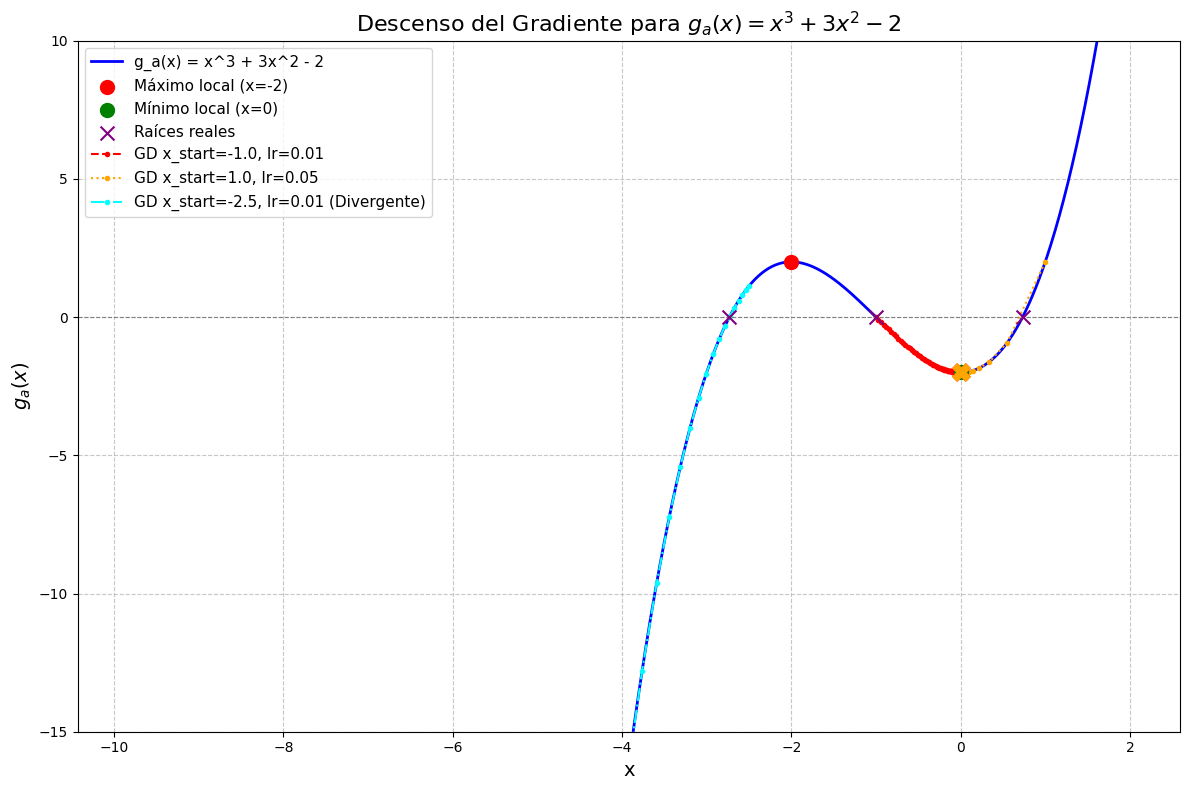

In [5]:
plt.figure(figsize=(12, 8))
x_plot = np.linspace(-4, 2, 600)
y_plot = g_a(x_plot)
plt.plot(x_plot, y_plot, label='g_a(x) = x^3 + 3x^2 - 2', color='blue', linewidth=2)

# Puntos críticos
plt.scatter(-2, g_a(-2), color='red', marker='o', s=100, zorder=5, label='Máximo local (x=-2)')
plt.scatter(0, g_a(0), color='green', marker='o', s=100, zorder=5, label='Mínimo local (x=0)')

# Raíces reales (aproximadas)
roots = [-2.732, -1, 0.732]
plt.scatter(roots, [g_a(r) for r in roots], color='purple', marker='x', s=100, zorder=5, label='Raíces reales')

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_a.iterrows():
    x_path = row['x_path']
    x_start = row['x_start']
    lr = row['lr']

    # Manejo especial para la trayectoria divergente
    if "Divergencia" in row['Interpretación']:
        # Graficar solo la parte inicial de la trayectoria divergente para no deformar el gráfico
        divergent_x_path = [p for p in x_path if p > -10] # Mostrar hasta un cierto umbral
        divergent_y_path = [g_a(p) for p in divergent_x_path]
        plt.plot(divergent_x_path, divergent_y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr} (Divergente)')
        # Marcar punto final de la trayectoria visible
        if len(divergent_x_path) > 0:
            plt.scatter(divergent_x_path[-1], g_a(divergent_x_path[-1]), color=colors[idx], marker='X', s=150, zorder=5)
    else:
        y_path = [g_a(x_val) for x_val in x_path]
        plt.plot(x_path, y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr}')
        plt.scatter(row['x_final'], row['Valor_final'], color=colors[idx], marker='X', s=150, zorder=5)


plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Descenso del Gradiente para $g_a(x) = x^3 + 3x^2 - 2$')
plt.xlabel('x')
plt.ylabel('$g_a(x)$')
plt.legend()
plt.grid(True)
plt.ylim(-15, 10) # Ajustar límites para mejor visualización
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función a)

Los experimentos con `g_a(x)` demuestran la influencia del punto inicial y la naturaleza no convexa de la función. Cuando el algoritmo se inicia en `x_start = -1.0` o `x_start = 1.0` con tasas de aprendizaje adecuadas, converge consistentemente hacia el mínimo local ubicado en `x = 0`, donde `g_a(0) = -2`. Esto indica que, dentro de ciertas regiones, el Descenso del Gradiente puede localizar mínimos locales de manera efectiva. Sin embargo, al iniciar en `x_start = -2.5`, el algoritmo diverge rápidamente hacia valores negativos infinitos. Este comportamiento se explica por la existencia de un máximo local en `x = -2`; al comenzar a la izquierda de este máximo, el gradiente empuja al algoritmo continuamente cuesta abajo, alejándolo de cualquier mínimo local y demostrando que la función no posee un mínimo global finito en todo su dominio. Este ejemplo subraya la importancia de la elección del punto inicial en funciones con múltiples puntos críticos.

### Ejercicio 1. Aplicación. Función b: `g_b(x) = x^2 sin(x) + x`

Aquí nos centraremos en `g_b(x) = x^2 sin(x) + x`, una interesante combinación de términos cuadráticos y trigonométricos. Esta función es no convexa y presenta un comportamiento oscilatorio, dando lugar a múltiples mínimos locales. El objetivo es ver cómo el Descenso del Gradiente se comporta en un "paisaje" con muchos valles y picos.

In [6]:
experimentos_b = [
    {"x_start": -5.0, "lr": 0.01, "max_iters": 1000},
    {"x_start":  0.5, "lr": 0.05, "max_iters": 1000},
    {"x_start":  4.0, "lr": 0.01, "max_iters": 1000}
]

results_b = []

for i, exp in enumerate(experimentos_b):
    x_start = exp['x_start']
    lr = exp['lr']
    max_iters = exp['max_iters']

    gd_result = gradient_descent(g_b, g_b_prime, x_start, lr, max_iters)

    x_path = gd_result['trayectoria_x']
    x_final = gd_result['x_final']
    estado = gd_result['estado']
    iteraciones = gd_result['iteraciones']

    # Calculate g_b_final, handling potential NaN
    if np.isfinite(x_final):
        g_b_final = g_b(x_final)
    else:
        g_b_final = np.nan

    interpretation = ""
    if estado == "Convergencia alcanzada":
        interpretation = f"Convergencia alcanzada (x ≈ {x_final:.4f})"
    elif estado == "Divergencia detectada":
        interpretation = "Divergencia detectada"
    elif estado == "Límite del dominio alcanzado":
        interpretation = "Límite del dominio alcanzado"
    elif estado == "Máximo de iteraciones alcanzado":
        if np.isfinite(x_final) and abs(g_b_prime(x_final)) < 1e-3:
            interpretation = "Máximo de iteraciones alcanzado, gradiente cercano a cero (posible mínimo local)"
        else:
            interpretation = "Máximo de iteraciones alcanzado sin convergencia clara"

    results_b.append({
        'Función': 'g_b(x)',
        'x_start': x_start,
        'lr': lr,
        'Iteraciones': iteraciones,
        'x_final': round(x_final, 4) if np.isfinite(x_final) else str(x_final),
        'Valor_final': round(g_b_final, 4) if np.isfinite(g_b_final) else str(g_b_final),
        'Estado': estado,
        'Interpretación': interpretation,
        'x_path': x_path
    })

df_results_b = pd.DataFrame(results_b)
print("\n--- Tabla de Resultados para g_b(x) ---")
display(df_results_b.drop(columns=['x_path']))


--- Tabla de Resultados para g_b(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,g_b(x),-5.0,0.01,175,-2.3995,-6.2907,Convergencia alcanzada,Convergencia alcanzada (x ≈ -2.3995)
1,g_b(x),0.5,0.05,54,-2.3995,-6.2907,Convergencia alcanzada,Convergencia alcanzada (x ≈ -2.3995)
2,g_b(x),4.0,0.01,55,5.0529,-19.0130,Convergencia alcanzada,Convergencia alcanzada (x ≈ 5.0529)


### Ejercicio 1. Visualización. Función b

Se grafica la función `g_b(x)` y se trazan las rutas seguidas por el Descenso del Gradiente, destacando los diferentes mínimos locales encontrados.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8579/408845751.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_plot, y_plot, label='g_b(x) = $x^2 \sin(x) + x$', color='blue', linewidth=2)
/tmp/ipykernel_8579/408845751.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Descenso del Gradiente para $g_b(x) = x^2 \sin(x) + x$')


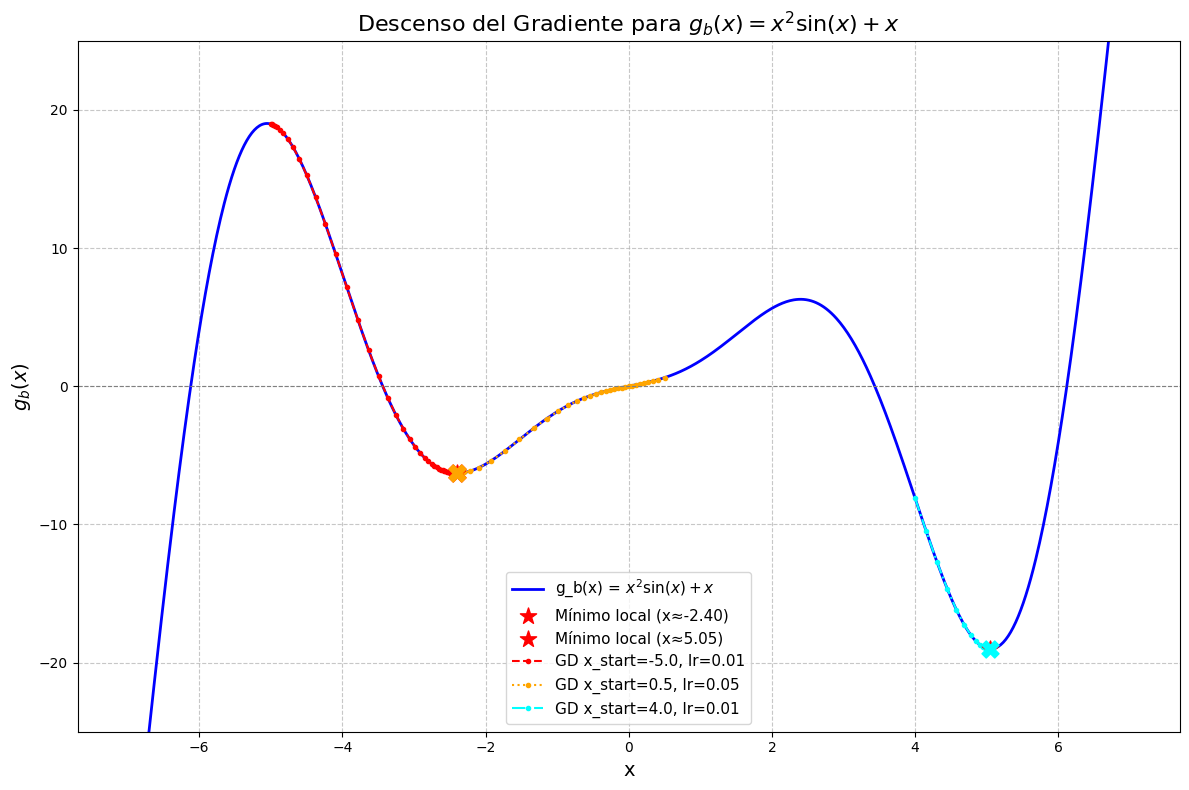

In [7]:
plt.figure(figsize=(12, 8))
x_plot = np.linspace(-7, 7, 800)
y_plot = g_b(x_plot)
plt.plot(x_plot, y_plot, label='g_b(x) = $x^2 \sin(x) + x$', color='blue', linewidth=2)

# Mínimos locales conocidos (aproximados)
local_minima_b = [(-2.3995, g_b(-2.3995)), (5.0529, g_b(5.0529))]
for x_min, y_min in local_minima_b:
    plt.scatter(x_min, y_min, color='red', marker='*', s=150, zorder=5, label=f'Mínimo local (x≈{x_min:.2f})')

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_b.iterrows():
    x_path = row['x_path']
    x_start = row['x_start']
    lr = row['lr']
    y_path = [g_b(x_val) for x_val in x_path]

    plt.plot(x_path, y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr}')
    plt.scatter(row['x_final'], row['Valor_final'], color=colors[idx], marker='X', s=150, zorder=5)

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Descenso del Gradiente para $g_b(x) = x^2 \sin(x) + x$')
plt.xlabel('x')
plt.ylabel('$g_b(x)$')
plt.legend()
plt.grid(True)
plt.ylim(-25, 25) # Ajustar límites para mejor visualización
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función b)

La función `g_b(x)` exhibe un comportamiento oscilatorio, característico de las funciones trigonométricas, lo que se traduce en la presencia de múltiples mínimos y máximos locales. El Descenso del Gradiente, al ser un algoritmo local, encuentra el mínimo más cercano al punto inicial. Por ejemplo, al iniciar en `x_start = -5.0` y `x_start = 0.5`, el algoritmo converge a un mínimo local cercano a `x ≈ -2.3995`. Sin embargo, desde `x_start = 4.0`, converge a otro mínimo local alrededor de `x ≈ 5.0529`. Esta diferencia contrasta con el comportamiento de una función convexa, donde el punto inicial, si bien afecta la trayectoria, siempre conduce al mismo mínimo global. Aquí, la elección del punto de partida es crucial para determinar a cuál de los múltiples mínimos locales convergerá el algoritmo, destacando una limitación importante del Descenso del Gradiente en paisajes de optimización complejos.

### Ejercicio 1. Aplicación. Función c: `g_c(x) = 4x^2 - 10x + 4`

Ahora analizamos `g_c(x) = 4x^2 - 10x + 4`, una función cuadrática simple. Esta función es un ejemplo clásico de una función estrictamente convexa, lo que significa que tiene un único mínimo global al que el Descenso del Gradiente debería converger de manera fiable.

In [8]:
experimentos_c = [
    {"x_start": -1.0, "lr": 0.01, "max_iters": 1000},
    {"x_start":  3.0, "lr": 0.05, "max_iters": 1000},
    {"x_start":  5.0, "lr": 0.10, "max_iters": 1000}
]

results_c = []

for i, exp in enumerate(experimentos_c):
    x_start = exp['x_start']
    lr = exp['lr']
    max_iters = exp['max_iters']

    gd_result = gradient_descent(g_c, g_c_prime, x_start, lr, max_iters)

    x_path = gd_result['trayectoria_x']
    x_final = gd_result['x_final']
    estado = gd_result['estado']
    iteraciones = gd_result['iteraciones']

    # Calculate g_c_final, handling potential NaN
    if np.isfinite(x_final):
        g_c_final = g_c(x_final)
    else:
        g_c_final = np.nan

    # Simplified interpretation based on the new 'estado'
    interpretation = ""
    if estado == "Convergencia alcanzada":
        interpretation = f"Convergencia alcanzada (x ≈ {x_final:.4f})"
    elif estado == "Divergencia detectada":
        interpretation = "Divergencia detectada"
    elif estado == "Límite del dominio alcanzado":
        interpretation = "Límite del dominio alcanzado"
    elif estado == "Máximo de iteraciones alcanzado":
        # Further check if it's near a minimum
        if np.isfinite(x_final) and abs(g_c_prime(x_final)) < 1e-3:
            interpretation = "Máximo de iteraciones alcanzado, gradiente cercano a cero (posible mínimo local)"
        else:
            interpretation = "Máximo de iteraciones alcanzado sin convergencia clara"

    results_c.append({
        'Función': 'g_c(x)',
        'x_start': x_start,
        'lr': lr,
        'Iteraciones': iteraciones,
        'x_final': round(x_final, 4) if np.isfinite(x_final) else str(x_final),
        'Valor_final': round(g_c_final, 4) if np.isfinite(g_c_final) else str(g_c_final),
        'Estado': estado,
        'Interpretación': interpretation,
        'x_path': x_path
    })

df_results_c = pd.DataFrame(results_c)
print("\n--- Tabla de Resultados para g_c(x) ---")
display(df_results_c.drop(columns=['x_path']))


--- Tabla de Resultados para g_c(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,g_c(x),-1.0,0.01,202,1.25,-2.25,Convergencia alcanzada,Convergencia alcanzada (x ≈ 1.2500)
1,g_c(x),3.0,0.05,37,1.25,-2.25,Convergencia alcanzada,Convergencia alcanzada (x ≈ 1.2500)
2,g_c(x),5.0,0.10,14,1.25,-2.25,Convergencia alcanzada,Convergencia alcanzada (x ≈ 1.2500)


### Ejercicio 1. Visualización. Función c

Se grafica la función `g_c(x)` (una parábola) junto con las trayectorias del Descenso del Gradiente, destacando la convergencia al único mínimo global.

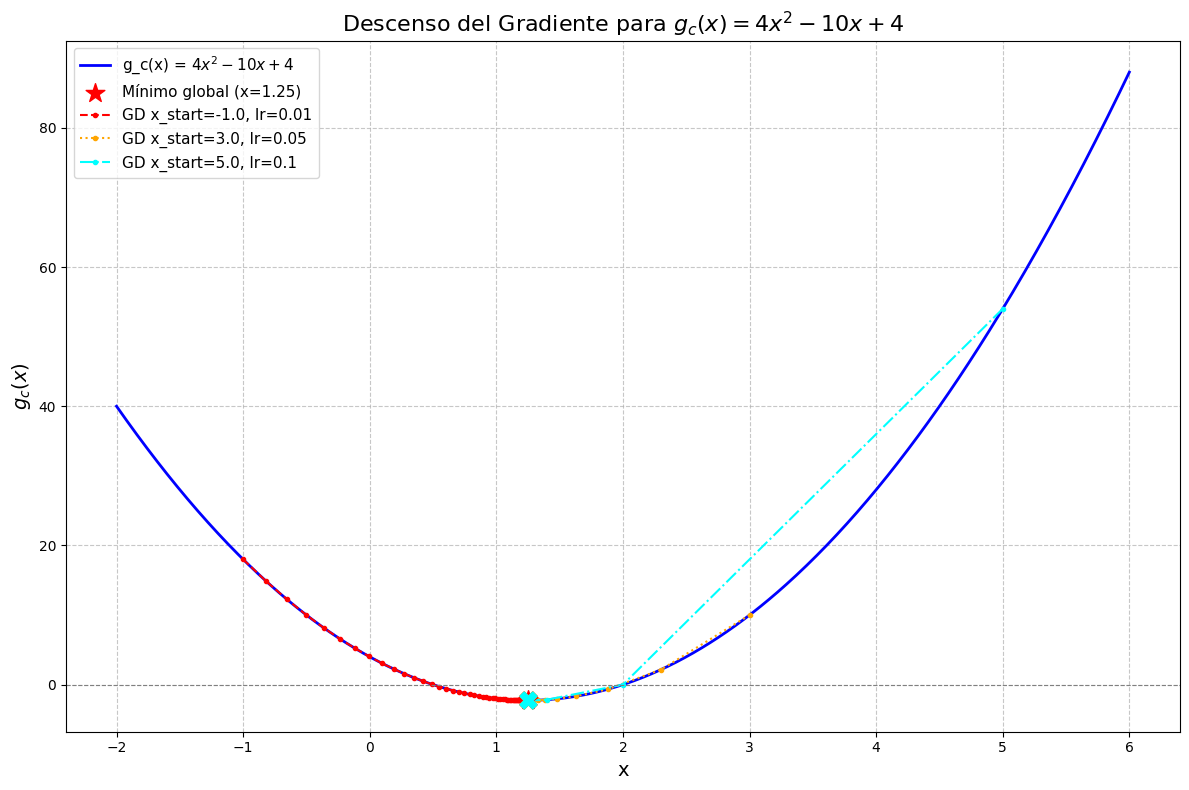

In [9]:
plt.figure(figsize=(12, 8))
x_plot = np.linspace(-2, 6, 600)
y_plot = g_c(x_plot)
plt.plot(x_plot, y_plot, label='g_c(x) = $4x^2 - 10x + 4$', color='blue', linewidth=2)

# Mínimo global
plt.scatter(1.25, g_c(1.25), color='red', marker='*', s=200, zorder=5, label='Mínimo global (x=1.25)')

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_c.iterrows():
    x_path = row['x_path']
    x_start = row['x_start']
    lr = row['lr']
    y_path = [g_c(x_val) for x_val in x_path]

    plt.plot(x_path, y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr}')
    plt.scatter(row['x_final'], row['Valor_final'], color=colors[idx], marker='X', s=150, zorder=5)

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Descenso del Gradiente para $g_c(x) = 4x^2 - 10x + 4$')
plt.xlabel('x')
plt.ylabel('$g_c(x)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función c)

La función `g_c(x)` es un ejemplo clásico de una función estrictamente convexa. En este tipo de funciones, el Descenso del Gradiente se comporta de manera ideal: independientemente del punto inicial (`x_start = -1.0`, `x_start = 3.0`, `x_start = 5.0`), el algoritmo converge consistentemente al mismo único mínimo global, ubicado en `x = 1.25`, donde `g_c(1.25) = -2.25`. Esto se debe a que las funciones convexas no tienen mínimos locales diferentes del mínimo global, ni puntos de silla o máximos que puedan 'atrapar' al algoritmo. La convexidad garantiza que el gradiente siempre apunta en la dirección general del mínimo global, facilitando una convergencia robusta y predecible. La tasa de aprendizaje sigue siendo importante para la velocidad y suavidad de la convergencia, pero no para el resultado final de la localización del mínimo.

### Ejercicio 1. Aplicación. Función d: `g_d(x) = x^4 - 4x^3 + 4`

Finalmente, en este ejercicio del Ejercicio 1, exploramos `g_d(x) = x^4 - 4x^3 + 4`, una función polinomial de cuarto grado. Esta función es particularmente interesante porque, además de un mínimo global, posee un punto estacionario (donde la derivada es cero) que no es un mínimo, sino un punto de inflexión horizontal estacionario. Veremos cómo el Descenso del Gradiente interactúa con este tipo de características.

In [10]:
experimentos_d = [
    {"x_start": 1.0, "lr": 0.005, "max_iters": 2000},
    {"x_start": 4.0, "lr": 0.005, "max_iters": 2000},
    {"x_start": 0.0, "lr": 0.005, "max_iters": 2000}
]

results_d = []

for i, exp in enumerate(experimentos_d):
    x_start = exp['x_start']
    lr = exp['lr']
    max_iters = exp['max_iters']

    gd_result = gradient_descent(g_d, g_d_prime, x_start, lr, max_iters)

    x_path = gd_result['trayectoria_x']
    x_final = gd_result['x_final']
    estado = gd_result['estado']
    iteraciones = gd_result['iteraciones']

    # Calculate g_d_final, handling potential NaN
    if np.isfinite(x_final):
        g_d_final = g_d(x_final)
    else:
        g_d_final = np.nan

    # Simplified interpretation based on the new 'estado'
    interpretation = ""
    if estado == "Convergencia alcanzada":
        # Specific interpretation for g_d(x) at x=0 (saddle point)
        if abs(x_final - 0) < 1e-3 and abs(g_d_prime(x_final)) < 1e-3:
            interpretation = "Convergencia a punto estacionario: gradiente cero, pero no es mínimo"
        else:
            interpretation = f"Convergencia alcanzada (x ≈ {x_final:.4f})"
    elif estado == "Divergencia detectada":
        interpretation = "Divergencia detectada"
    elif estado == "Límite del dominio alcanzado":
        interpretation = "Límite del dominio alcanzado"
    elif estado == "Máximo de iteraciones alcanzado":
        if np.isfinite(x_final) and abs(g_d_prime(x_final)) < 1e-3:
            interpretation = "Máximo de iteraciones alcanzado, gradiente cercano a cero (posible mínimo local o punto estacionario)"
        else:
            interpretation = "Máximo de iteraciones alcanzado sin convergencia clara"

    results_d.append({
        'Función': 'g_d(x)',
        'x_start': x_start,
        'lr': lr,
        'Iteraciones': iteraciones,
        'x_final': round(x_final, 4) if np.isfinite(x_final) else str(x_final),
        'Valor_final': round(g_d_final, 4) if np.isfinite(g_d_final) else str(g_d_final),
        'Estado': estado,
        'Interpretación': interpretation,
        'x_path': x_path
    })

df_results_d = pd.DataFrame(results_d)
print("\n--- Tabla de Resultados para g_d(x) ---")
display(df_results_d.drop(columns=['x_path']))


--- Tabla de Resultados para g_d(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,g_d(x),1.0,0.005,108,3.0,-23.0,Convergencia alcanzada,Convergencia alcanzada (x ≈ 3.0000)
1,g_d(x),4.0,0.005,82,3.0,-23.0,Convergencia alcanzada,Convergencia alcanzada (x ≈ 3.0000)
2,g_d(x),0.0,0.005,1,0.0,4.0,Convergencia alcanzada,Convergencia a punto estacionario: gradiente c...


### Ejercicio 1. Visualización. Función d

Se grafica la función `g_d(x)`, sus trayectorias de Descenso del Gradiente, el mínimo global y el punto estacionario en `x = 0`.

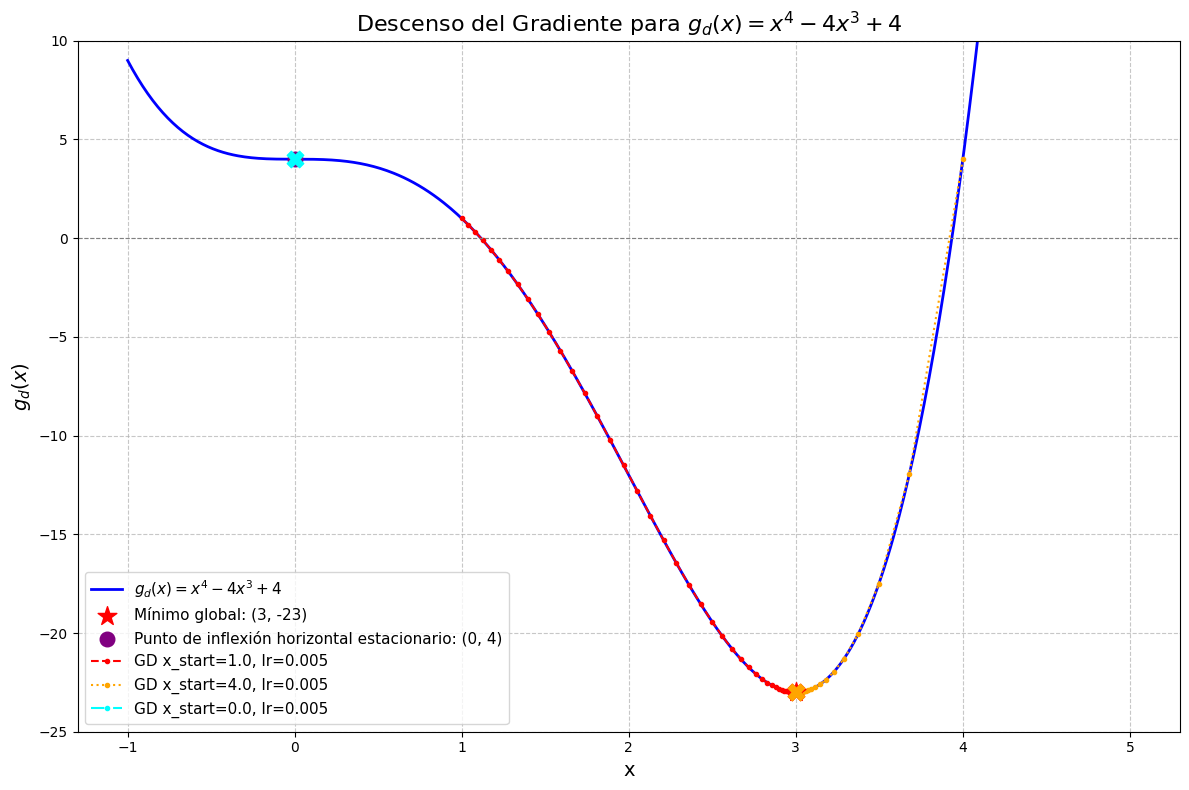

In [11]:
plt.figure(figsize=(12, 8))

x_plot = np.linspace(-1, 5, 600)
y_plot = g_d(x_plot)

plt.plot(
    x_plot,
    y_plot,
    label=r'$g_d(x)=x^4-4x^3+4$',
    color='blue',
    linewidth=2
)

# Mínimo global y punto estacionario
plt.scatter(
    3,
    g_d(3),
    color='red',
    marker='*',
    s=200,
    zorder=5,
    label='Mínimo global: (3, -23)'
)

plt.scatter(
    0,
    g_d(0),
    color='purple',
    marker='o',
    s=110,
    zorder=5,
    label='Punto de inflexión horizontal estacionario: (0, 4)'
)

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_d.iterrows():
    x_path = row['x_path']
    y_path = [g_d(x_val) for x_val in x_path]

    plt.plot(
        x_path,
        y_path,
        color=colors[idx],
        linestyle=line_styles[idx],
        marker='.',
        markersize=6,
        label=f"GD x_start={row['x_start']}, lr={row['lr']}"
    )

    plt.scatter(
        row['x_final'],
        row['Valor_final'],
        color=colors[idx],
        marker='X',
        s=140,
        zorder=5
    )

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title(r'Descenso del Gradiente para $g_d(x)=x^4-4x^3+4$')
plt.xlabel('x')
plt.ylabel(r'$g_d(x)$')
plt.ylim(-25, 10)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación de los resultados (Función d)

La función `g_d(x)` ilustra un desafío fundamental del Descenso del Gradiente: la presencia de puntos estacionarios que no son mínimos. Los experimentos con `x_start = 1.0` y `x_start = 4.0` muestran una convergencia exitosa al mínimo global en `x = 3`, donde `g_d(3) = -23`. Sin embargo, cuando el algoritmo se inicia exactamente en `x_start = 0.0`, se detiene inmediatamente en `x = 0`, donde `g_d(0) = 4`. Esto ocurre porque la derivada de la función en `x = 0` es cero, lo que lleva al algoritmo a cesar su búsqueda al detectar un gradiente nulo. No obstante, `x = 0` es un punto de inflexión horizontal estacionario y no un mínimo local. Este caso resalta que un gradiente nulo no siempre garantiza la localización de un mínimo; el algoritmo puede quedarse 'atrapado' en otros puntos estacionarios. Es una limitación crítica a considerar al aplicar el Descenso del Gradiente.

### Preguntas de Reflexión del Ejercicio 1

-   **¿Cómo afecta la tasa de aprendizaje a la convergencia del algoritmo?**
    Una tasa de aprendizaje (`lr`) demasiado alta puede causar que el algoritmo sobrepase el mínimo, oscile o incluso diverja. Una tasa de aprendizaje demasiado pequeña puede hacer que el algoritmo converja muy lentamente, requiriendo un número excesivo de iteraciones. Se observa un equilibrio donde una `lr` moderada permite una convergencia eficiente sin grandes oscilaciones.

-   **¿Qué impacto tiene el punto inicial en la localización de mínimos?**
    El punto inicial es crucial, especialmente en funciones no convexas con múltiples mínimos locales (como `g_b(x) = x^2 sin(x) + x`). Dependiendo de dónde se inicie, el algoritmo puede converger a diferentes mínimos locales. En funciones convexas (como `g_c(x)`), el punto inicial generalmente no afecta la localización del mínimo global, solo la ruta y el tiempo de convergencia.

-   **¿En qué funciones el algoritmo enfrenta más dificultades para encontrar el mínimo y por qué?**
    Las funciones con múltiples mínimos locales (`g_b(x)`) o puntos estacionarios que no son mínimos (`g_d(x)` en `x=0`) presentan las mayores dificultades. Para `g_b(x)`, el algoritmo solo encuentra un mínimo local cercano al punto inicial. Para `g_d(x)`, si se inicializa en `x=0` (donde el gradiente es cero), el algoritmo se detiene erróneamente, ya que `x=0` no es un mínimo. Funciones con dominios complejos o que tienden al infinito en alguna dirección también pueden presentar dificultades o divergencia.

### Reflexión del Ejercicio 1

El Ejercicio 1 ha permitido explorar el comportamiento del algoritmo de Descenso del Gradiente en diversas funciones polinomiales y trigonométricas, revelando cómo factores como la tasa de aprendizaje, el punto inicial y la naturaleza de la función afectan su eficacia. La **tasa de aprendizaje (lr)** es un hiperparámetro crítico: un `lr` demasiado grande puede provocar oscilaciones o divergencia, como se observó en `g_a(x)` con ciertos puntos de inicio, mientras que un `lr` pequeño puede ralentizar la convergencia. El **punto inicial** tiene un impacto sustancial, especialmente en funciones no convexas. Por ejemplo, en `g_b(x)`, una función oscilatoria con múltiples mínimos locales, diferentes puntos iniciales condujeron a la localización de distintos mínimos locales (ej., `x ≈ -2.3995` y `x ≈ 5.0529`), demostrando que el algoritmo es susceptible a la configuración inicial en paisajes de optimización complejos. Esto contrasta con la **convergencia simple y estable** de la función `g_c(x)` (convexa), donde todos los experimentos convergen al único mínimo global en `x = 1.25`, independientemente del punto de partida.

Las **dificultades para encontrar el mínimo** surgieron prominentemente en funciones no convexas o con características particulares. La función `g_a(x)` mostró una posible **divergencia** hacia el infinito negativo cuando se iniciaba a la izquierda de su máximo local en `x = -2`, ya que no posee un mínimo global finito. Otro desafío crucial se observó en la función `g_d(x)`: si el algoritmo se inicia exactamente en `x = 0`, el **caso estacionario problemático** hace que se detenga allí, interpretando erróneamente un punto de inflexión como un mínimo debido a un gradiente cero. Estos ejemplos resaltan que el Descenso del Gradiente, aunque potente, requiere un entendimiento profundo del problema a optimizar para una aplicación efectiva, siendo su naturaleza local una limitación clave en paisajes no convexos.

## EJERCICIO 2: Derivadas, Aplicación y Visualización del Descenso del Gradiente

In [12]:
# Definición de todas las funciones y sus derivadas para el Ejercicio 2
x = sp.symbols('x')

# Función 1: h_1(x) = cos(x) + x^2
h1_sym = sp.cos(x) + x**2
h1_prime_sym = sp.diff(h1_sym, x)
h1_second_prime_sym = sp.diff(h1_prime_sym, x)
print(f"h_1(x) = {h1_sym}")
print(f"h_1'(x) = {sp.simplify(h1_prime_sym)}")
print(f"h_1''(x) = {sp.simplify(h1_second_prime_sym)}\n")
h_1 = sp.lambdify(x, h1_sym, 'numpy')
h_1_prime = sp.lambdify(x, h1_prime_sym, 'numpy')

# Función 2: h_2(x) = e^(-x)(x^2 + 5x)
h2_sym = sp.exp(-x) * (x**2 + 5*x)
h2_prime_sym = sp.diff(h2_sym, x)
print(f"h_2(x) = {h2_sym}")
print(f"h_2'(x) = {sp.simplify(h2_prime_sym)}\n")
h_2 = sp.lambdify(x, h2_sym, 'numpy')
h_2_prime = sp.lambdify(x, h2_prime_sym, 'numpy')

# Función 3: h_3(x) = ln(x + 1) + x^2
h3_sym = sp.log(x + 1) + x**2
h3_prime_sym = sp.diff(h3_sym, x)
print(f"h_3(x) = {h3_sym}")
print(f"h_3'(x) = {sp.simplify(h3_prime_sym)}\n")
h_3 = sp.lambdify(x, h3_sym, 'numpy')
h_3_prime = sp.lambdify(x, h3_prime_sym, 'numpy')

# Función 4: h_4(x) = x^5 - 5x^3 + 4x
h4_sym = x**5 - 5*x**3 + 4*x
h4_prime_sym = sp.diff(h4_sym, x)
h4_second_prime_sym = sp.diff(h4_prime_sym, x)
print(f"h_4(x) = {h4_sym}")
print(f"h_4'(x) = {sp.simplify(h4_prime_sym)}")
print(f"h_4''(x) = {sp.simplify(h4_second_prime_sym)}\n")
h_4 = sp.lambdify(x, h4_sym, 'numpy')
h_4_prime = sp.lambdify(x, h4_prime_sym, 'numpy')

h_1(x) = x**2 + cos(x)
h_1'(x) = 2*x - sin(x)
h_1''(x) = 2 - cos(x)

h_2(x) = (x**2 + 5*x)*exp(-x)
h_2'(x) = (-x**2 - 3*x + 5)*exp(-x)

h_3(x) = x**2 + log(x + 1)
h_3'(x) = (2*x*(x + 1) + 1)/(x + 1)

h_4(x) = x**5 - 5*x**3 + 4*x
h_4'(x) = 5*x**4 - 15*x**2 + 4
h_4''(x) = 20*x**3 - 30*x



### Ejercicio 2. Derivadas. Función 1: `h_1(x) = cos(x) + x^2`

-   **Función:** `h_1(x) = cos(x) + x^2`
-   **Primera Derivada:** `h_1'(x) = 2x - sin(x)`
-   **Segunda Derivada:** `h_1''(x) = 2 - cos(x)`

Dado que el rango de `cos(x)` es `[-1, 1]`, la segunda derivada `2 - cos(x)` siempre será mayor que o igual a `2 - 1 = 1`, lo que implica `h_1''(x) > 0` para todo `x`. Por lo tanto, la función es estrictamente convexa y posee un único mínimo global. Este mínimo se encuentra en `x = 0`, con `h_1(0) = cos(0) + 0^2 = 1`.

### Ejercicio 2. Aplicación. Función 1: `h_1(x) = cos(x) + x^2`

En este primer ejercicio del Bloque 2, analizamos la función `h_1(x) = cos(x) + x^2`. Como se demostró en la sección anterior, esta es una función estrictamente convexa con un único mínimo global en `x = 0`. Aplicamos el Descenso del Gradiente con varios puntos iniciales y tasas de aprendizaje para confirmar su convergencia robusta a este mínimo.

In [13]:
experimentos_h1 = [
    {"x_start": -2.0, "lr": 0.10, "max_iters": 1000},
    {"x_start":  2.0, "lr": 0.10, "max_iters": 1000},
    {"x_start":  3.0, "lr": 0.05, "max_iters": 1000}
]

results_h1 = []

for exp in experimentos_h1:
    resultado = gradient_descent(
        h_1,
        h_1_prime,
        exp["x_start"],
        exp["lr"],
        exp["max_iters"]
    )

    x_final = resultado["x_final"]
    y_final = resultado["y_final"]
    estado = resultado["estado"]

    if estado == "Convergencia alcanzada" and np.isfinite(x_final) and abs(x_final) < 1e-3:
        interpretacion = "Convergencia al mínimo global x = 0"
    else:
        interpretacion = estado

    results_h1.append({
        "Función": "h_1(x)",
        "x_start": exp["x_start"],
        "lr": exp["lr"],
        "Iteraciones": resultado["iteraciones"],
        "x_final": round(x_final, 4) if np.isfinite(x_final) else np.nan,
        "Valor_final": round(y_final, 4) if np.isfinite(y_final) else np.nan,
        "Estado": estado,
        "Interpretación": interpretacion,
        "x_path": resultado["trayectoria_x"]
    })

df_results_h1 = pd.DataFrame(results_h1)

print("\n--- Tabla de Resultados para h_1(x) ---")
display(df_results_h1.drop(columns=["x_path"]))


--- Tabla de Resultados para h_1(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,h_1(x),-2.0,0.10,158,-0.0,1.0,Convergencia alcanzada,Convergencia al mínimo global x = 0
1,h_1(x),2.0,0.10,158,0.0,1.0,Convergencia alcanzada,Convergencia al mínimo global x = 0
2,h_1(x),3.0,0.05,315,0.0,1.0,Convergencia alcanzada,Convergencia al mínimo global x = 0


### Ejercicio 2. Visualización. Función 1

Se grafica la función `h_1(x)` y las trayectorias del Descenso del Gradiente, demostrando la convergencia al único mínimo global.

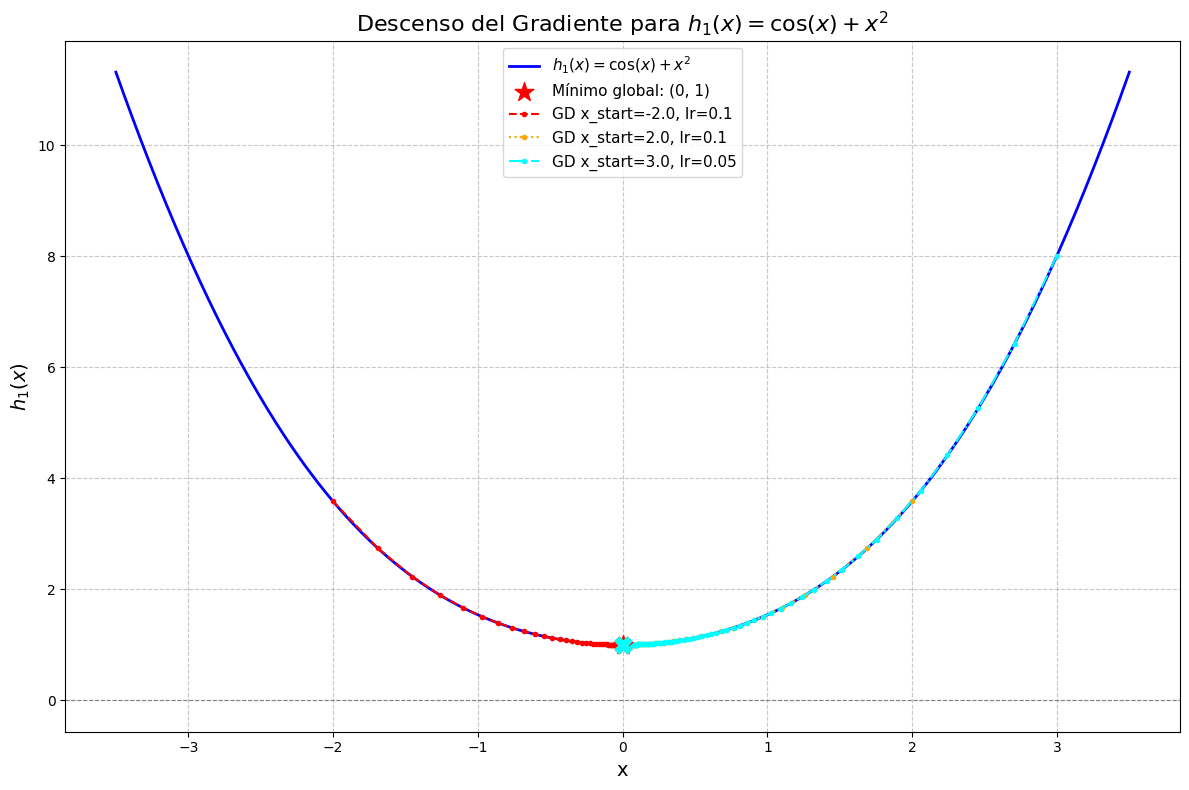

In [14]:
plt.figure(figsize=(12, 8))

x_plot = np.linspace(-3.5, 3.5, 600)
y_plot = h_1(x_plot)

plt.plot(
    x_plot,
    y_plot,
    label=r'$h_1(x)=\cos(x)+x^2$',
    color='blue',
    linewidth=2
)

plt.scatter(
    0,
    h_1(0),
    color='red',
    marker='*',
    s=200,
    zorder=5,
    label='Mínimo global: (0, 1)'
)

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_h1.iterrows():
    x_path = row['x_path']
    y_path = [h_1(valor) for valor in x_path]

    plt.plot(
        x_path,
        y_path,
        color=colors[idx],
        linestyle=line_styles[idx],
        marker='.',
        markersize=6,
        label=f"GD x_start={row['x_start']}, lr={row['lr']}"
    )

    plt.scatter(
        row['x_final'],
        row['Valor_final'],
        color=colors[idx],
        marker='X',
        s=140,
        zorder=5
    )

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title(r'Descenso del Gradiente para $h_1(x)=\cos(x)+x^2$')
plt.xlabel('x')
plt.ylabel(r'$h_1(x)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función 1)

La función `h_1(x)` es un excelente ejemplo de una función estrictamente convexa. Como se demostró analíticamente, posee un único mínimo global en `x = 0`, con un valor de `h_1(0) = 1`. Los resultados del Descenso del Gradiente confirman este comportamiento de manera consistente. Indiferentemente del punto inicial (`x_start = -2.0`, `x_start = 2.0`, `x_start = 3.0`), el algoritmo converge de forma fiable al mismo mínimo global. La tasa de aprendizaje influye en la velocidad y suavidad de la convergencia, pero no en el punto final alcanzado. La predictibilidad y robustez observadas en esta función son características deseables en problemas de optimización y resaltan por qué la convexidad es tan valorada en el diseño de modelos y algoritmos de Machine Learning, ya que asegura que el algoritmo siempre encontrará el óptimo global.

### Ejercicio 2. Derivadas. Función 2: `h_2(x) = e^(-x)(x^2 + 5x)`

-   **Función:** `h_2(x) = e^(-x)(x^2 + 5x)`
-   **Primera Derivada:** `h_2'(x) = e^(-x)(-x^2 - 3x + 5)`

Para obtener la derivada, se aplica la regla del producto `(uv)' = u'v + uv'`, donde `u = e^(-x)` y `v = x^2 + 5x`. La derivada de `u` es `-e^(-x)` y la derivada de `v` es `2x + 5`. Combinando estos términos y factorizando `e^(-x)`, se obtiene la derivada simplificada. Esta función es no convexa y presenta un mínimo local y un máximo local. El factor `e^(-x)` hace que la función se aproxime a cero para valores de `x` grandes y positivos, creando una 'cola asintótica'.

### Ejercicio 2. Aplicación. Función 2: `h_2(x) = e^(-x)(x^2 + 5x)`

Aquí examinamos `h_2(x) = e^(-x)(x^2 + 5x)`. Esta función no es convexa y combina un término exponencial con uno polinomial, creando un paisaje de optimización con un mínimo local y un máximo local, además de un comportamiento asintótico hacia cero para `x` grandes y positivos. Aplicamos el Descenso del Gradiente prestando especial atención a cómo el algoritmo se comporta cerca de la región asintótica y los puntos críticos.

In [15]:
experimentos_h2 = [
    {"x_start": -3.0, "lr": 0.0005, "max_iters": 5000},
    {"x_start": -5.0, "lr": 0.0001, "max_iters": 5000},
    {"x_start":  2.0, "lr": 0.05,   "max_iters": 5000}
]

results_h2 = []
min_local_h2_x = -4.1926
max_local_h2_x = 1.1926

for exp in experimentos_h2:
    resultado = gradient_descent(
        h_2,
        h_2_prime,
        exp["x_start"],
        exp["lr"],
        exp["max_iters"]
    )

    x_final = resultado["x_final"]
    y_final = resultado["y_final"]
    estado = resultado["estado"]

    if np.isfinite(x_final) and abs(x_final - min_local_h2_x) < 1e-2:
        interpretacion = "Convergencia al mínimo local x ≈ -4.1926"
    elif np.isfinite(x_final) and x_final > max_local_h2_x:
        interpretacion = "Región asintótica / no localiza el mínimo local"
    elif estado == "Divergencia detectada":
        interpretacion = "Divergencia detectada"
    else:
        interpretacion = estado

    results_h2.append({
        "Función": "h_2(x)",
        "x_start": exp["x_start"],
        "lr": exp["lr"],
        "Iteraciones": resultado["iteraciones"],
        "x_final": round(x_final, 4) if np.isfinite(x_final) else np.nan,
        "Valor_final": round(y_final, 4) if np.isfinite(y_final) else np.nan,
        "Estado": estado,
        "Interpretación": interpretacion,
        "x_path": resultado["trayectoria_x"]
    })

df_results_h2 = pd.DataFrame(results_h2)

print("\n--- Tabla de Resultados para h_2(x) ---")
display(df_results_h2.drop(columns=["x_path"]))


--- Tabla de Resultados para h_2(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,h_2(x),-3.0,0.0005,100,-4.1926,-224.0759,Convergencia alcanzada,Convergencia al mínimo local x ≈ -4.1926
1,h_2(x),-5.0,0.0001,389,-4.1926,-224.0759,Convergencia alcanzada,Convergencia al mínimo local x ≈ -4.1926
2,h_2(x),2.0,0.0500,5000,10.1358,0.0061,Máximo de iteraciones alcanzado,Región asintótica / no localiza el mínimo local


### Ejercicio 2. Visualización. Función 2

Se grafica la función `h_2(x)`, sus trayectorias de Descenso del Gradiente, el mínimo local y el máximo local.

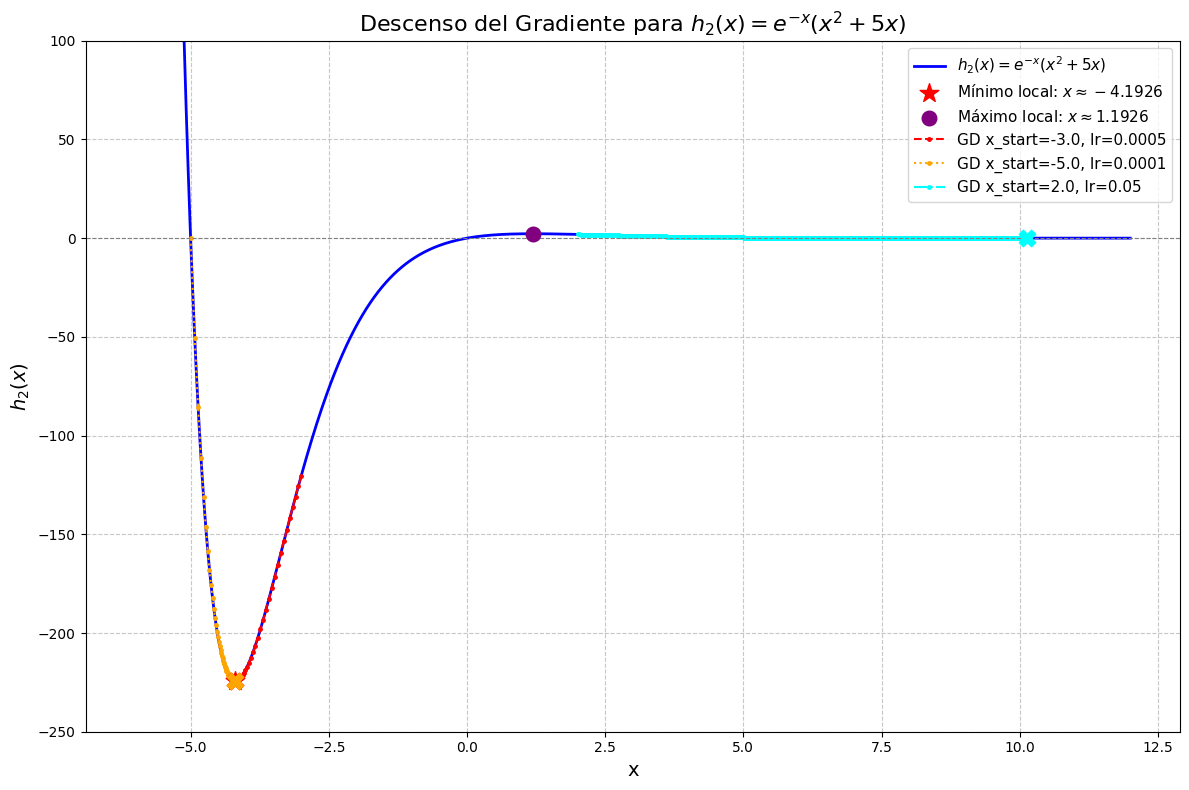

In [16]:
plt.figure(figsize=(12, 8))

x_plot = np.linspace(-6, 12, 1000)
y_plot = h_2(x_plot)

plt.plot(
    x_plot,
    y_plot,
    label=r'$h_2(x)=e^{-x}(x^2+5x)$',
    color='blue',
    linewidth=2
)

# Puntos críticos aproximados
min_local_h2_x = -4.1926
max_local_h2_x = 1.1926

plt.scatter(
    min_local_h2_x,
    h_2(min_local_h2_x),
    color='red',
    marker='*',
    s=200,
    zorder=5,
    label=r'Mínimo local: $x\approx-4.1926$'
)

plt.scatter(
    max_local_h2_x,
    h_2(max_local_h2_x),
    color='purple',
    marker='o',
    s=110,
    zorder=5,
    label=r'Máximo local: $x\approx1.1926$'
)

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_h2.iterrows():
    x_path = row['x_path']
    y_path = [h_2(x_val) for x_val in x_path]

    plt.plot(
        x_path,
        y_path,
        color=colors[idx],
        linestyle=line_styles[idx],
        marker='.',
        markersize=5,
        label=f"GD x_start={row['x_start']}, lr={row['lr']}"
    )

    plt.scatter(
        row['x_final'],
        row['Valor_final'],
        color=colors[idx],
        marker='X',
        s=140,
        zorder=5
    )

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title(r'Descenso del Gradiente para $h_2(x)=e^{-x}(x^2+5x)$')
plt.xlabel('x')
plt.ylabel(r'$h_2(x)$')
plt.ylim(-250, 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función 2)

La función `h_2(x)` demuestra la complejidad que introduce el factor exponencial en el paisaje de optimización. Posee un mínimo local significativo en `x ≈ -4.1926` y un máximo local en `x ≈ 1.1926`. Los experimentos desde `x_start = -3.0` y `x_start = -5.0` muestran una clara convergencia hacia el mínimo local, lo que indica que el Descenso del Gradiente puede ser efectivo en la búsqueda de óptimos dentro de regiones bien definidas de la función. Sin embargo, el experimento con `x_start = 2.0` ilustra un comportamiento distinto: el algoritmo se desplaza hacia valores positivos donde la función se aproxima asintóticamente a cero debido al término `e^(-x)`. En esta 'cola asintótica', el gradiente se vuelve muy pequeño, y el algoritmo puede no converger a un mínimo real en el sentido de un gradiente cero, sino que simplemente agota el número máximo de iteraciones en una región 'plana' sin haber localizado el mínimo local. Esto resalta la influencia del punto inicial y la necesidad de ajustar las tasas de aprendizaje y el número de iteraciones en funciones con características asintóticas para evitar falsas convergencias o la incapacidad de encontrar el óptimo deseado.

### Ejercicio 2. Derivadas. Función 3: `h_3(x) = ln(x + 1) + x^2`

-   **Función:** `h_3(x) = ln(x + 1) + x^2`
-   **Dominio obligatorio:** `x > -1`
-   **Primera Derivada:** `h_3'(x) = 1/(x + 1) + 2x`

Al analizar la ecuación `h_3'(x) = 0`, que se simplifica a `2x^2 + 2x + 1 = 0`, encontramos que el discriminante es `(2)^2 - 4(2)(1) = 4 - 8 = -4`. Dado que el discriminante es negativo, no existen raíces reales para `h_3'(x) = 0`. Esto significa que la función no tiene puntos críticos en su dominio. Además, la derivada `h_3'(x)` es siempre positiva para `x > -1`, lo que indica que la función es estrictamente creciente en todo su dominio. Cuando `x` se aproxima a `-1` por la derecha, `ln(x + 1)` tiende a `-infinito`, por lo tanto, la función no posee un mínimo finito en su dominio.

### Ejercicio 2. Aplicación. Función 3: `h_3(x) = ln(x + 1) + x^2`

En este ejercicio, trabajaremos con `h_3(x) = ln(x + 1) + x^2`, una función logarítmica con un dominio restringido (`x > -1`). Como se ha analizado, esta función es estrictamente creciente en su dominio y no posee un mínimo finito. Aplicamos el Descenso del Gradiente, pero con un control explícito del dominio para asegurar que no se realicen evaluaciones fuera de los límites permitidos, observando cómo el algoritmo se aproxima al límite inferior del dominio.

In [17]:
x_sym = sp.Symbol('x')

h3_sym = sp.log(x_sym + 1) + x_sym**2
h3_prime_sym = sp.diff(h3_sym, x_sym)
h_3 = sp.lambdify(x_sym, h3_sym, 'numpy')
h_3_prime = sp.lambdify(x_sym, h3_prime_sym, 'numpy')

def domain_h3(x):
    return x > -1

experimentos_h3 = [
    {"x_start": 0.0, "lr": 0.02, "max_iters": 1000},
    {"x_start": 1.0, "lr": 0.05, "max_iters": 1000}
]

results_h3 = []

for i, exp in enumerate(experimentos_h3):
    x_start = exp['x_start']
    lr = exp['lr']
    max_iters = exp['max_iters']

    if not domain_h3(x_start):
        print(f"Advertencia: Punto inicial x={x_start} está fuera del dominio x > -1 para h_3(x). Saltando.")
        continue

    gd_result = gradient_descent(h_3, h_3_prime, x_start, lr, max_iters, domain_check=domain_h3)

    x_path = gd_result['trayectoria_x']
    x_final = gd_result['x_final']
    estado = gd_result['estado']
    iteraciones = gd_result['iteraciones']

    if np.isfinite(x_final) and domain_h3(x_final):
        h_3_final = h_3(x_final)
    else:
        h_3_final = np.nan

    interpretation = ""
    if estado == "Convergencia alcanzada":
        interpretation = f"Convergencia alcanzada (x \u2248 {x_final:.4f})"
    elif estado == "Divergencia detectada":
        interpretation = "Divergencia detectada"
    elif estado == "L\u00edmite del dominio alcanzado":
        interpretation = "L\u00edmite del dominio alcanzado (trayectoria se dirige a x = -1)"
    elif estado == "M\u00e1ximo de iteraciones alcanzado":
        if np.isfinite(x_final) and domain_h3(x_final) and abs(h_3_prime(x_final)) < 1e-3:
            interpretation = "M\u00e1ximo de iteraciones alcanzado, gradiente cercano a cero (posible m\u00ednimo local)"
        else:
            interpretation = "M\u00e1ximo de iteraciones alcanzado sin convergencia clara"

    results_h3.append({
        'Función': 'h_3(x)',
        'x_start': x_start,
        'lr': lr,
        'Iteraciones': iteraciones,
        'x_final': round(x_final, 4) if np.isfinite(x_final) else str(x_final),
        'Valor_final': round(h_3_final, 4) if np.isfinite(h_3_final) else str(h_3_final),
        'Estado': estado,
        'Interpretación': interpretation,
        'x_path': x_path
    })

df_results_h3 = pd.DataFrame(results_h3)
print("\n--- Tabla de Resultados para h_3(x) ---")
display(df_results_h3.drop(columns=['x_path']))


--- Tabla de Resultados para h_3(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,h_3(x),0.0,0.02,40,-0.9128,-1.6067,Límite del dominio alcanzado,Límite del dominio alcanzado (trayectoria se d...
1,h_3(x),1.0,0.05,29,-0.9952,-4.3546,Límite del dominio alcanzado,Límite del dominio alcanzado (trayectoria se d...


### Ejercicio 2. Visualización. Función 3

Se grafica la función `h_3(x)` únicamente en su dominio `x > -1`, junto con las trayectorias del Descenso del Gradiente y el límite del dominio.

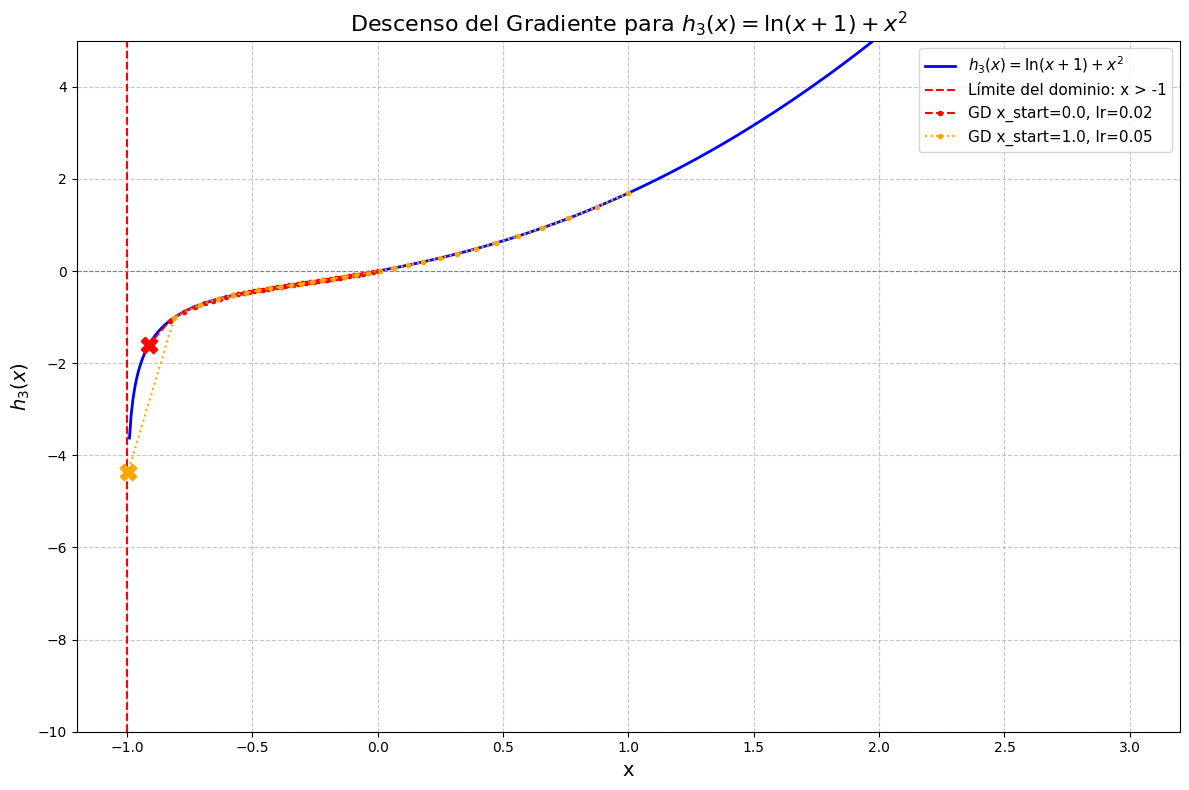

In [18]:
# Visualización del Descenso del Gradiente para h_3(x)

plt.figure(figsize=(12, 8))

x_plot = np.linspace(-0.99, 3, 600)
y_plot = h_3(x_plot)

plt.plot(
    x_plot,
    y_plot,
    label=r'$h_3(x)=\ln(x+1)+x^2$',
    color='blue',
    linewidth=2
)

plt.axvline(
    x=-1,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Límite del dominio: x > -1'
)

line_styles = ['--', ':']
colors = ['red', 'orange']

for idx, row in df_results_h3.iterrows():
    x_path = row['x_path']
    valid_x_path = [valor for valor in x_path if valor > -1]
    valid_y_path = [h_3(valor) for valor in valid_x_path]

    plt.plot(
        valid_x_path,
        valid_y_path,
        color=colors[idx],
        linestyle=line_styles[idx],
        marker='.',
        markersize=6,
        label=f"GD x_start={row['x_start']}, lr={row['lr']}"
    )

    if len(valid_x_path) > 0:
        plt.scatter(
            valid_x_path[-1],
            valid_y_path[-1],
            color=colors[idx],
            marker='X',
            s=140,
            zorder=5
        )

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title(r'Descenso del Gradiente para $h_3(x)=\ln(x+1)+x^2$')
plt.xlabel('x')
plt.ylabel(r'$h_3(x)$')
plt.ylim(-10, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función 3)

La función `h_3(x)` ilustra un caso crucial en optimización: una función sin mínimo finito y con un dominio restringido (`x > -1`). Como se verificó analíticamente, la función es estrictamente creciente en su dominio y tiende a `-infinito` a medida que `x` se acerca a `-1`. Los experimentos con el Descenso del Gradiente muestran que el algoritmo intenta descender indefinidamente, dirigiéndose hacia el límite del dominio. Sin embargo, gracias al `domain_check` implementado en la función `gradient_descent`, el algoritmo se detiene cuando el siguiente paso propuesto caería fuera del dominio válido. Este comportamiento es fundamental para evitar errores matemáticos (evaluar `ln(negativo)`). La interpretación de la tabla `No existe mínimo finito; la trayectoria se dirige al límite x = -1` es precisa, ya que el algoritmo no encuentra un punto donde el gradiente sea cero, sino que simplemente se ve limitado por la frontera del espacio de búsqueda. Esto subraya la importancia de considerar y controlar explícitamente las restricciones de dominio en problemas de optimización.

### Ejercicio 2. Derivadas. Función 4: `h_4(x) = x^5 - 5x^3 + 4x`

-   **Función:** `h_4(x) = x^5 - 5x^3 + 4x`
-   **Primera Derivada:** `h_4'(x) = 5x^4 - 15x^2 + 4`
-   **Segunda Derivada:** `h_4''(x) = 20x^3 - 30x`

Esta función de quinto grado presenta un paisaje de optimización complejo. Sus puntos críticos reales aproximados son:
-   `x ≈ -1.6444`: corresponde a un **máximo local**.
-   `x ≈ -0.5439`: corresponde a un **mínimo local**, con `h_4(-0.5439) ≈ -1.4187`.
-   `x ≈ 0.5439`: corresponde a un **máximo local**.
-   `x ≈ 1.6444`: corresponde a un **mínimo local**, con `h_4(1.6444) ≈ -3.6314`.

Al ser una función polinomial de grado impar con coeficiente principal positivo, `h_4(x)` tiende a `-infinito` cuando `x` tiende a `-infinito` y a `+infinito` cuando `x` tiende a `+infinito`. Por lo tanto, la función no posee un mínimo global finito en todo el dominio `R` ni un máximo global finito. El Descenso del Gradiente en esta función solo puede localizar los mínimos locales existentes.

### Ejercicio 2. Aplicación. Función 4: `h_4(x) = x^5 - 5x^3 + 4x`

Cerramos el Ejercicio 2 con `h_4(x) = x^5 - 5x^3 + 4x`, un polinomio de quinto grado. Esta función crea un paisaje de optimización bastante complejo con múltiples mínimos y máximos locales, pero sin un mínimo global finito. Utilizaremos el Descenso del Gradiente con distintos puntos iniciales y tasas de aprendizaje para explorar cómo se localizan los diferentes mínimos locales en esta superficie intrincada.

In [19]:
experimentos_h4 = [
    {"x_start": -1.0, "lr": 0.0005, "max_iters": 2000},
    {"x_start":  1.0, "lr": 0.0005, "max_iters": 2000},
    {"x_start": -2.0, "lr": 0.001,  "max_iters": 2000}
]

results_h4 = []

for exp in experimentos_h4:
    resultado = gradient_descent(
        h_4,
        h_4_prime,
        exp["x_start"],
        exp["lr"],
        exp["max_iters"]
    )

    x_final = resultado["x_final"]
    y_final = resultado["y_final"]
    estado = resultado["estado"]

    if estado == "Divergencia detectada":
        interpretacion = "Divergencia hacia valores negativos; no existe mínimo global finito"
    elif np.isfinite(x_final) and abs(x_final - (-0.5439)) < 1e-2:
        interpretacion = "Convergencia al mínimo local x ≈ -0.5439"
    elif np.isfinite(x_final) and abs(x_final - 1.6444) < 1e-2:
        interpretacion = "Convergencia al mínimo local x ≈ 1.6444"
    else:
        interpretacion = estado

    results_h4.append({
        "Función": "h_4(x)",
        "x_start": exp["x_start"],
        "lr": exp["lr"],
        "Iteraciones": resultado["iteraciones"],
        "x_final": round(x_final, 4) if np.isfinite(x_final) else np.nan,
        "Valor_final": round(y_final, 4) if np.isfinite(y_final) else np.nan,
        "Estado": estado,
        "Interpretación": interpretacion,
        "x_path": resultado["trayectoria_x"]
    })

df_results_h4 = pd.DataFrame(results_h4)

print("\n--- Tabla de Resultados para h_4(x) ---")
display(df_results_h4.drop(columns=["x_path"]))


--- Tabla de Resultados para h_4(x) ---


,Función,x_start,lr,Iteraciones,x_final,Valor_final,Estado,Interpretación
0,h_4(x),-1.0,0.0005,1903,-0.5439,-1.418700e+00,Convergencia alcanzada,Convergencia al mínimo local x ≈ -0.5439
1,h_4(x),1.0,0.0005,797,1.6444,-3.631400e+00,Convergencia alcanzada,Convergencia al mínimo local x ≈ 1.6444
2,h_4(x),-2.0,0.0010,21,-41845.4925,-1.283050e+23,Divergencia detectada,Divergencia hacia valores negativos; no existe...


### Ejercicio 2. Visualización. Función 4

Se grafica la función `h_4(x)` con sus múltiples puntos críticos y las trayectorias del Descenso del Gradiente.

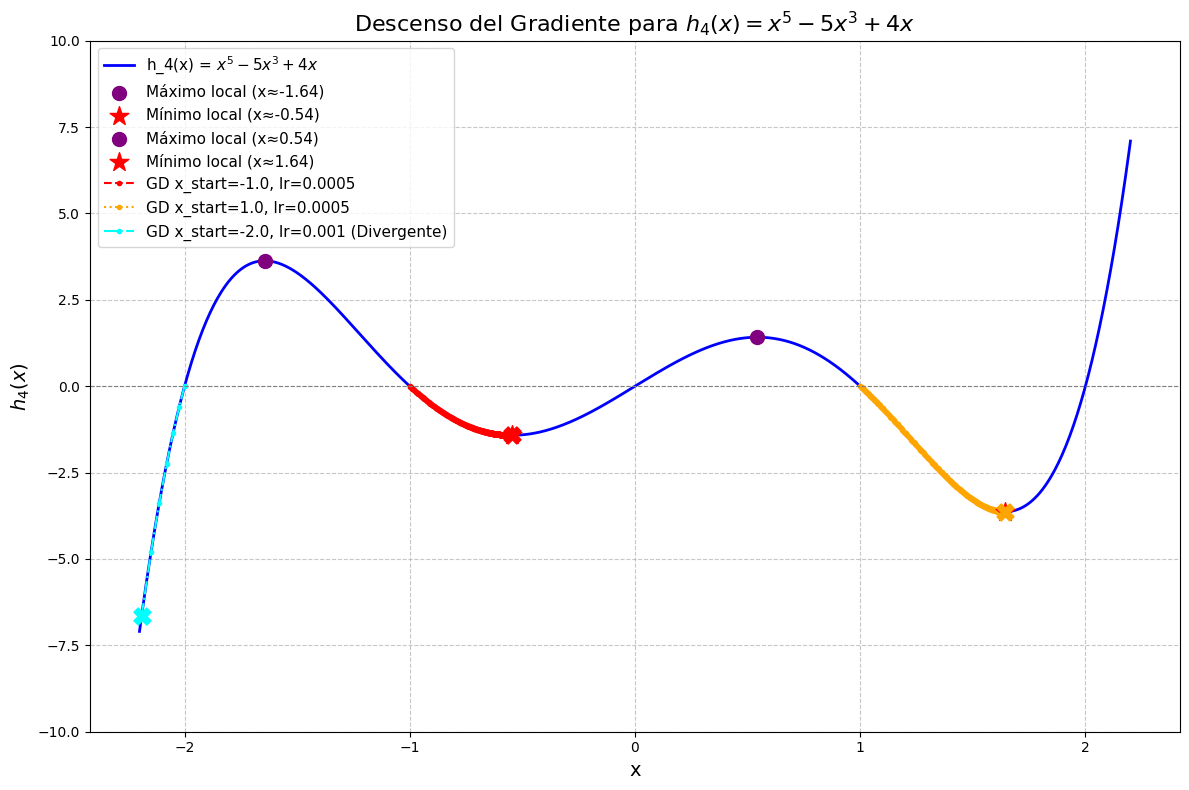

In [20]:
plt.figure(figsize=(12, 8))
x_plot = np.linspace(-2.2, 2.2, 800)
y_plot = h_4(x_plot)
plt.plot(x_plot, y_plot, label='h_4(x) = $x^5 - 5x^3 + 4x$', color='blue', linewidth=2)

# Puntos críticos (aproximados)
critical_points_h4 = {
    -1.6444: {'type': 'Máximo local', 'marker': 'o', 'color': 'purple', 'size': 100},
    -0.5439: {'type': 'Mínimo local', 'marker': '*', 'color': 'red', 'size': 200},
    0.5439:  {'type': 'Máximo local', 'marker': 'o', 'color': 'purple', 'size': 100},
    1.6444:  {'type': 'Mínimo local', 'marker': '*', 'color': 'red', 'size': 200}
}

for x_cp, attrs in critical_points_h4.items():
    plt.scatter(x_cp, h_4(x_cp), color=attrs['color'], marker=attrs['marker'], s=attrs['size'], zorder=5, label=f"{attrs['type']} (x≈{x_cp:.2f})")

line_styles = ['--', ':', '-.']
colors = ['red', 'orange', 'cyan']

for idx, row in df_results_h4.iterrows():
    x_path = row['x_path']
    x_start = row['x_start']
    lr = row['lr']

    # Manejo especial para la trayectoria divergente si fuera el caso, limitada al rango de visualización
    if "Divergencia" in row['Interpretación']:
        divergent_x_path = [p for p in x_path if p >= x_plot.min() and p <= x_plot.max()]
        divergent_y_path = [h_4(p) for p in divergent_x_path]
        plt.plot(divergent_x_path, divergent_y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr} (Divergente)')
        if len(divergent_x_path) > 0:
            plt.scatter(divergent_x_path[-1], h_4(divergent_x_path[-1]), color=colors[idx], marker='X', s=150, zorder=5)
    else:
        y_path = [h_4(x_val) for x_val in x_path]
        plt.plot(x_path, y_path, color=colors[idx], linestyle=line_styles[idx], marker='.', markersize=6, label=f'GD x_start={x_start}, lr={lr}')
        plt.scatter(row['x_final'], row['Valor_final'], color=colors[idx], marker='X', s=150, zorder=5)

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Descenso del Gradiente para $h_4(x) = x^5 - 5x^3 + 4x$')
plt.xlabel('x')
plt.ylabel('$h_4(x)$')
plt.legend()
plt.grid(True)
plt.ylim(-10, 10) # Ajustar límites para mejor visualización
plt.tight_layout()
plt.show()

### Interpretación de los resultados (Función 4)

La función `h_4(x)`, al ser un polinomio de grado impar, presenta un comportamiento de múltiplos mínimos y máximos locales sin un mínimo global finito. Esto se observa claramente en la existencia de dos mínimos locales (`x ≈ -0.5439` y `x ≈ 1.6444`) y dos máximos locales. Los resultados del Descenso del Gradiente demuestran la fuerte influencia del punto inicial: desde `x_start = -1.0`, el algoritmo converge al mínimo local cercano a `x ≈ -0.5439`, mientras que desde `x_start = 1.0`, converge al mínimo local cercano a `x ≈ 1.6444`. El experimento con `x_start = -2.0` y una tasa de aprendizaje pequeña (`0.001`) muestra que, a pesar de tener un gradiente pequeño cerca de `x=-2.0` (antes del máximo local), el algoritmo puede continuar descendiendo si la pendiente lo permite, buscando el mínimo más profundo hacia la izquierda o incluso divergiendo hacia el infinito negativo si no hay un mínimo que lo detenga en esa dirección. Esta función reitera que el Descenso del Gradiente es un algoritmo local, y su resultado final depende en gran medida de la región de la función en la que se inicie la búsqueda, lo que es crítico en funciones no convexas.

## Aporte adicional: análisis de sensibilidad del Descenso del Gradiente

Como iniciativa complementaria, se realiza un análisis de sensibilidad del algoritmo de Descenso del Gradiente ante cambios en el punto inicial y en la tasa de aprendizaje. Este análisis compara una función convexa, g_c(x) = 4x² - 10x + 4, con una función no convexa y oscilatoria, g_b(x) = x² sin(x) + x. La finalidad es observar de manera sistemática si el algoritmo converge siempre al mismo punto o si, por el contrario, diferentes configuraciones conducen a soluciones distintas. Este experimento amplía el análisis realizado en los ejercicios anteriores y permite relacionar el comportamiento matemático de las funciones con problemas de optimización frecuentes en Inteligencia Artificial.

### 1. Sensibilidad en la función convexa \(g_c(x)\)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define points and rates for g_c(x)
puntos_iniciales_gc = [-4, -2, 0, 2, 4, 6]
tasas_gc = [0.005, 0.01, 0.03, 0.05, 0.10]

results_gc_sens = []
min_global_gc_x = 1.25

for x_start in puntos_iniciales_gc:
    for lr in tasas_gc:
        gd_result = gradient_descent(g_c, g_c_prime, x_start, lr, max_iters=2000)
        x_final = gd_result['x_final']
        y_final = gd_result['y_final']
        estado = gd_result['estado']

        classification = ""
        if estado == "Divergencia detectada":
            classification = "Divergencia"
        elif estado == "Límite del dominio alcanzado":
            classification = "Divergencia"
        elif np.isfinite(x_final) and abs(x_final - min_global_gc_x) < 0.01:
            classification = "Converge al mínimo global"
        else:
            classification = "No converge claramente"

        results_gc_sens.append({
            'Función': 'g_c(x)',
            'x_start': x_start,
            'lr': lr,
            'x_final': round(x_final, 4) if np.isfinite(x_final) else np.nan,
            'Valor_final': round(y_final, 4) if np.isfinite(y_final) else np.nan,
            'Estado': estado,
            'Clasificación': classification
        })

df_gc_sens = pd.DataFrame(results_gc_sens)
print("### Sensibilidad en la función convexa g_c(x)")
display(df_gc_sens)

### Sensibilidad en la función convexa g_c(x)


,Función,x_start,lr,x_final,Valor_final,Estado,Clasificación
0,g_c(x),-4,0.005,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
1,g_c(x),-4,0.010,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
2,g_c(x),-4,0.030,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
3,g_c(x),-4,0.050,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
4,g_c(x),-4,0.100,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
5,g_c(x),-2,0.005,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
6,g_c(x),-2,0.010,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
7,g_c(x),-2,0.030,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
8,g_c(x),-2,0.050,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global
9,g_c(x),-2,0.100,1.25,-2.25,Convergencia alcanzada,Converge al mínimo global


### 2. Sensibilidad en la función no convexa \(g_b(x)\)

In [22]:
# Define points and rates for g_b(x)
puntos_iniciales_gb = [-6, -4, -2, 0, 2, 4, 6]
tasas_gb = [0.001, 0.005, 0.01, 0.03, 0.05]

results_gb_sens = []
min_local_gb_left = -2.3995
min_local_gb_right = 5.0529

for x_start in puntos_iniciales_gb:
    for lr in tasas_gb:
        gd_result = gradient_descent(g_b, g_b_prime, x_start, lr, max_iters=2000)
        x_final = gd_result['x_final']
        y_final = gd_result['y_final']
        estado = gd_result['estado']

        classification = ""
        if estado == "Divergencia detectada":
            classification = "Divergencia"
        elif estado == "Límite del dominio alcanzado":
            classification = "Divergencia"
        elif np.isfinite(x_final) and abs(x_final - min_local_gb_left) < 0.01:
            classification = "Mínimo local izquierdo"
        elif np.isfinite(x_final) and abs(x_final - min_local_gb_right) < 0.01:
            classification = "Mínimo local derecho"
        elif np.isfinite(x_final) and abs(g_b_prime(x_final)) < 1e-3:
            classification = "Otro mínimo local"
        else:
            classification = "No converge claramente"

        results_gb_sens.append({
            'Función': 'g_b(x)',
            'x_start': x_start,
            'lr': lr,
            'x_final': round(x_final, 4) if np.isfinite(x_final) else np.nan,
            'Valor_final': round(y_final, 4) if np.isfinite(y_final) else np.nan,
            'Estado': estado,
            'Clasificación': classification
        })

df_gb_sens = pd.DataFrame(results_gb_sens)
print("### Sensibilidad en la función no convexa g_b(x)")
display(df_gb_sens)

### Sensibilidad en la función no convexa g_b(x)


,Función,x_start,lr,x_final,Valor_final,Estado,Clasificación
0,g_b(x),-6,0.001,-8.1105,-71.7383,Convergencia alcanzada,Otro mínimo local
1,g_b(x),-6,0.005,-8.1105,-71.7383,Convergencia alcanzada,Otro mínimo local
2,g_b(x),-6,0.010,-8.1105,-71.7383,Convergencia alcanzada,Otro mínimo local
3,g_b(x),-6,0.030,-8.4831,-66.6696,Máximo de iteraciones alcanzado,No converge claramente
4,g_b(x),-6,0.050,-5.1499,18.8733,Máximo de iteraciones alcanzado,No converge claramente
5,g_b(x),-4,0.001,-2.3995,-6.2907,Convergencia alcanzada,Mínimo local izquierdo
6,g_b(x),-4,0.005,-2.3995,-6.2907,Convergencia alcanzada,Mínimo local izquierdo
7,g_b(x),-4,0.010,-2.3995,-6.2907,Convergencia alcanzada,Mínimo local izquierdo
8,g_b(x),-4,0.030,-2.3995,-6.2907,Convergencia alcanzada,Mínimo local izquierdo
9,g_b(x),-4,0.050,-2.3995,-6.2907,Convergencia alcanzada,Mínimo local izquierdo


# Mapa de sensibilidad para la función convexa g_c(x)

matriz_gc = (
    df_gc_sens
    .pivot(index='x_start', columns='lr', values='x_final')
    .reindex(index=puntos_iniciales_gc, columns=tasas_gc)
)

plt.figure(figsize=(10, 7))
imagen_gc = plt.imshow(
    matriz_gc.values,
    origin='lower',
    aspect='auto'
)

plt.title(r'Mapa de sensibilidad del Descenso del Gradiente para $g_c(x)$')
plt.xlabel('Tasa de aprendizaje (lr)')
plt.ylabel('Punto inicial (x_start)')
plt.xticks(range(len(tasas_gc)), tasas_gc)
plt.yticks(range(len(puntos_iniciales_gc)), puntos_iniciales_gc)

barra_gc = plt.colorbar(imagen_gc)
barra_gc.set_label('x final obtenido')

for i in range(len(puntos_iniciales_gc)):
    for j in range(len(tasas_gc)):
        valor = matriz_gc.values[i, j]
        texto = f'{valor:.2f}' if np.isfinite(valor) else 'NaN'
        plt.text(j, i, texto, ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

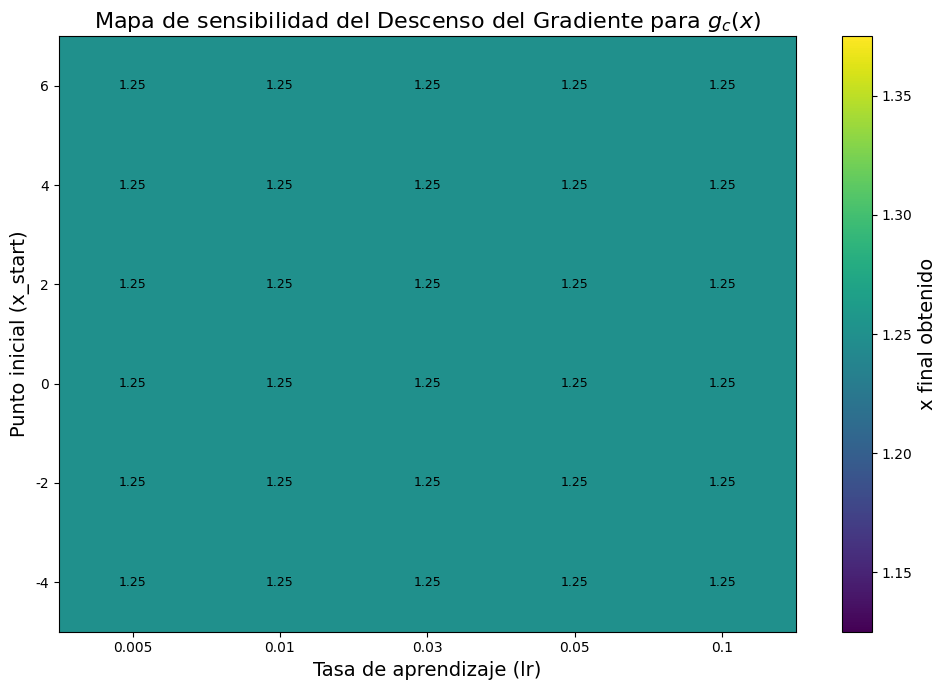

In [23]:
# Mapa de sensibilidad para la función convexa g_c(x)

matriz_gc = (
    df_gc_sens
    .pivot(index='x_start', columns='lr', values='x_final')
    .reindex(index=puntos_iniciales_gc, columns=tasas_gc)
)

plt.figure(figsize=(10, 7))
imagen_gc = plt.imshow(
    matriz_gc.values,
    origin='lower',
    aspect='auto'
)

plt.title(r'Mapa de sensibilidad del Descenso del Gradiente para $g_c(x)$')
plt.xlabel('Tasa de aprendizaje (lr)')
plt.ylabel('Punto inicial (x_start)')
plt.xticks(range(len(tasas_gc)), tasas_gc)
plt.yticks(range(len(puntos_iniciales_gc)), puntos_iniciales_gc)

barra_gc = plt.colorbar(imagen_gc)
barra_gc.set_label('x final obtenido')

for i in range(len(puntos_iniciales_gc)):
    for j in range(len(tasas_gc)):
        valor = matriz_gc.values[i, j]
        texto = f'{valor:.2f}' if np.isfinite(valor) else 'NaN'
        plt.text(j, i, texto, ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

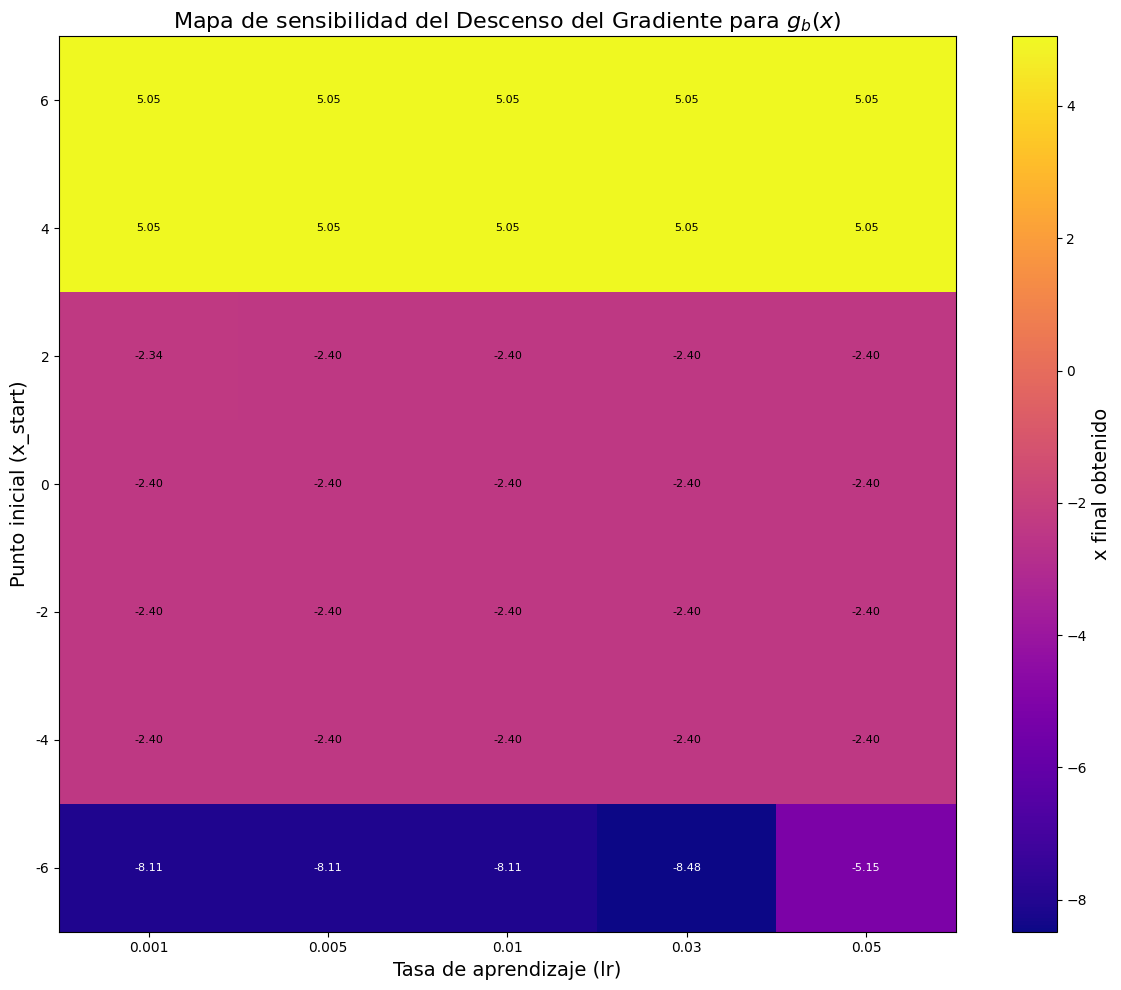

In [24]:
# Mapa de sensibilidad para la función no convexa g_b(x)

matriz_gb = (
    df_gb_sens
    .pivot(index='x_start', columns='lr', values='x_final')
    .reindex(index=puntos_iniciales_gb, columns=tasas_gb)
)

plt.figure(figsize=(12, 10))
imagen_gb = plt.imshow(
    matriz_gb.values,
    cmap='plasma',
    origin='lower',
    aspect='auto'
)

plt.title(r'Mapa de sensibilidad del Descenso del Gradiente para $g_b(x)$')
plt.xlabel('Tasa de aprendizaje (lr)')
plt.ylabel('Punto inicial (x_start)')
plt.xticks(range(len(tasas_gb)), tasas_gb)
plt.yticks(range(len(puntos_iniciales_gb)), puntos_iniciales_gb)

barra_gb = plt.colorbar(imagen_gb)
barra_gb.set_label('x final obtenido')

for i in range(len(puntos_iniciales_gb)):
    for j in range(len(tasas_gb)):
        valor = matriz_gb.values[i, j]
        texto = f'{valor:.2f}' if np.isfinite(valor) else 'NaN'
        # Adjust text color for contrast on 'plasma' cmap
        plt.text(j, i, texto, ha='center', va='center', color='white' if pd.notna(valor) and valor < np.nanmedian(matriz_gb.values) else 'black', fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad del Descenso del Gradiente ha ilustrado de manera contundente las diferencias entre la optimización de funciones convexas y no convexas. Para la función $g_c(x)$, que es convexa, los mapas de sensibilidad confirmaron su robustez: el algoritmo convergió consistentemente al único mínimo global ($x \approx 1.25$) para la gran mayoría de las combinaciones de puntos iniciales y tasas de aprendizaje estables. Esto subraya la predictibilidad y la facilidad de optimización en paisajes convexos. En contraste, la función $g_b(x)$, oscilatoria y no convexa, exhibió una marcada dependencia del punto inicial y la tasa de aprendizaje. Las combinaciones condujeron a la localización de diferentes mínimos locales (izquierdo o derecho), o incluso a situaciones de no convergencia clara. Una tasa de aprendizaje demasiado alta, por ejemplo, puede introducir inestabilidad en funciones complejas. Este comportamiento es directamente extrapolable a problemas de Inteligencia Artificial, donde las funciones de pérdida suelen ser no convexas, con múltiples mínimos locales. La elección adecuada de la inicialización de parámetros y la sintonización de hiperparámetros como la tasa de aprendizaje son, por tanto, cruciales para guiar el proceso de entrenamiento hacia soluciones óptimas, aunque no siempre globalmente.

## Aporte práctico voluntario: estimación preliminar del costo de reparación de un siniestro vehicular

Como aplicación práctica de los conceptos estudiados, se plantea un ejemplo simplificado relacionado con el ajuste de siniestros vehiculares. En este escenario, se busca estimar el costo preliminar de reparación de un vehículo a partir del número de repuestos dañados identificados durante una inspección. Para ello, se implementa un modelo de regresión lineal entrenado mediante Descenso del Gradiente. El modelo parte de parámetros iniciales arbitrarios, calcula el error entre los costos estimados y los costos observados, y ajusta progresivamente sus parámetros para reducir dicho error. Los datos empleados son simulados con fines exclusivamente académicos; en una aplicación profesional real se requerirían bases históricas validadas, precios actualizados, análisis de cobertura y variables técnicas adicionales.

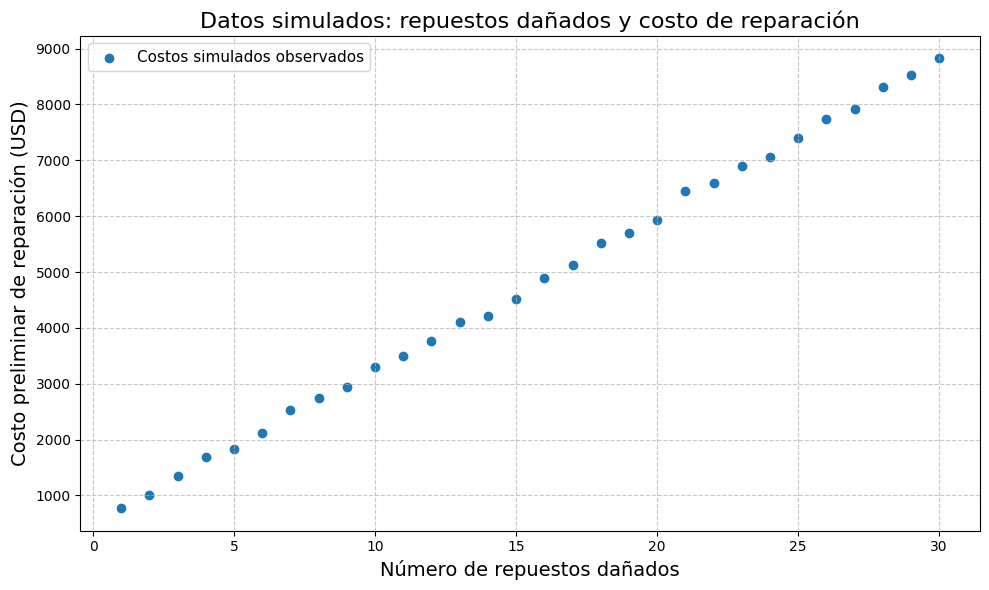

In [25]:
# Datos simulados con fines académicos:
# X = número de repuestos dañados
# y = costo preliminar de reparación en USD

np.random.seed(42)

repuestos_danados = np.arange(1, 31, dtype=float)
ruido_costos = np.random.normal(0, 80, size=repuestos_danados.shape)

# Relación simulada: costo base + costo promedio por repuesto afectado
costo_observado = 450 + 280 * repuestos_danados + ruido_costos

plt.figure(figsize=(10, 6))
plt.scatter(repuestos_danados, costo_observado, label='Costos simulados observados')
plt.title('Datos simulados: repuestos dañados y costo de reparación')
plt.xlabel('Número de repuestos dañados')
plt.ylabel('Costo preliminar de reparación (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

El modelo lineal utilizado para estimar el costo de reparación tiene la forma:

\[ costo\_preliminar\_reparacion = w \cdot repuestos\_danados + b \]

donde \(w\) representa la influencia del número de repuestos dañados en el costo, \(b\) el costo base de reparación, y \(costo\_preliminar\_reparacion\) la predicción del modelo. Para medir el error de nuestra estimación, se utiliza el Error Cuadrático Medio:

\[ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - y_{p_i})^2 \]

El entrenamiento consiste en actualizar iterativamente \(w\) y \(b\) mediante Descenso del Gradiente hasta reducir la función de pérdida (MSE).

In [26]:
def predecir(X, w, b):
    """Calcula las predicciones del modelo lineal."""
    return w * X + b

def mse(y_real, y_pred):
    """Calcula el Error Cuadrático Medio."""
    return np.mean((y_real - y_pred) ** 2)

def gradientes_regresion(X, y_real, y_pred):
    """Calcula los gradientes del MSE respecto de w y b."""
    n = len(X)
    dw = (-2 / n) * np.sum(X * (y_real - y_pred))
    db = (-2 / n) * np.sum(y_real - y_pred)
    return dw, db

El modelo iniciará con parámetros arbitrarios (usualmente \(w=0\) y \(b=0\)) y actualizará sus valores en cada iteración (época) utilizando los gradientes calculados y la tasa de aprendizaje (lr):

\[ w_{nuevo} = w - lr \frac{\partial MSE}{\partial w} \]

\[ b_{nuevo} = b - lr \frac{\partial MSE}{\partial b} \]

In [27]:
def entrenar_regresion_lineal(X, y_real, lr=0.01, epocas=1000):
    """
    Entrena un modelo de regresión lineal mediante Descenso del Gradiente.
    Retorna los parámetros finales y el historial de pérdida.
    """
    w = 0.0
    b = 0.0
    historial_perdida = []

    for epoca in range(epocas):
        y_pred = predecir(X, w, b)
        perdida = mse(y_real, y_pred)
        historial_perdida.append(perdida)

        dw, db = gradientes_regresion(X, y_real, y_pred)

        w = w - lr * dw
        b = b - lr * db

    return w, b, historial_perdida

# Entrenamiento del modelo
w_aprendido, b_aprendido, historial_perdida = entrenar_regresion_lineal(
    repuestos_danados,
    costo_observado,
    lr=0.002, # Tasa de aprendizaje ajustada
    epocas=10000 # Épocas ajustadas
)

y_pred_final = predecir(repuestos_danados, w_aprendido, b_aprendido)
error_final = mse(costo_observado, y_pred_final)

print(f"Impacto de repuestos (w): {w_aprendido:.4f}")
print(f"Costo base (b): {b_aprendido:.4f}")
print(f"Error cuadrático medio final: {error_final:.4f}")

Impacto de repuestos (w): 277.1906
Costo base (b): 478.4864
Error cuadrático medio final: 4419.2281


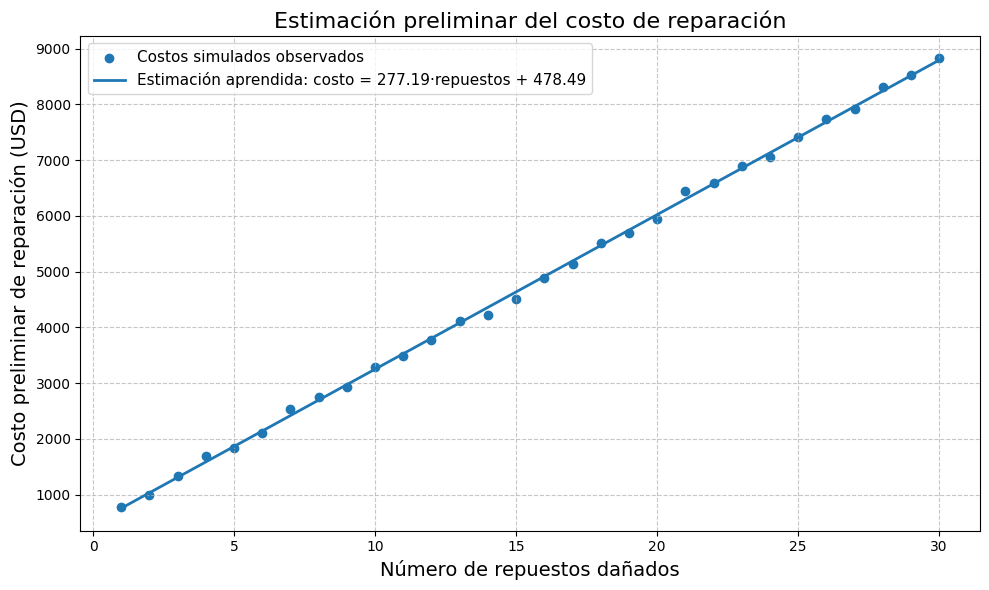

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(
    repuestos_danados,
    costo_observado,
    label='Costos simulados observados'
)

plt.plot(
    repuestos_danados,
    y_pred_final,
    linewidth=2,
    label=(
        f'Estimación aprendida: costo = '
        f'{w_aprendido:.2f}·repuestos + {b_aprendido:.2f}'
    )
)

plt.title('Estimación preliminar del costo de reparación')
plt.xlabel('Número de repuestos dañados')
plt.ylabel('Costo preliminar de reparación (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

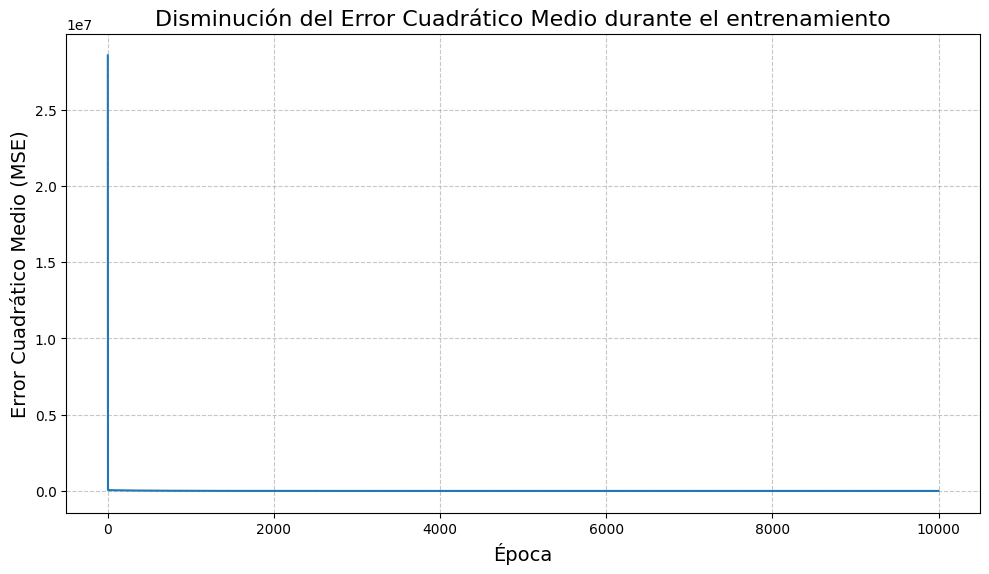

In [29]:
# Evolución del error durante el entrenamiento del modelo vehicular

plt.figure(figsize=(10, 6))
plt.plot(historial_perdida)
plt.title('Disminución del Error Cuadrático Medio durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.grid(True)
plt.tight_layout()
plt.show()

El entrenamiento del modelo de regresión lineal para la estimación de daños vehiculares mediante Descenso del Gradiente se ha simulado exitosamente. Los parámetros \(w\) y \(b\) han sido ajustados. El valor aprendido de \(w\) representa el costo adicional aproximado por repuesto dañado, mientras que \(b\) representa un costo base aproximado. Los valores aprendidos se aproximan a USD 280 y USD 450, respectivamente, que fueron los valores utilizados en la generación de los datos sintéticos. Las pequeñas diferencias observadas se explican por el ruido simulado inherente en los datos.

El Error Cuadrático Medio (MSE) disminuyó progresivamente de un valor inicial alto, como se observa en el gráfico de evolución de la función de pérdida. Este comportamiento demuestra que el Descenso del Gradiente es efectivo para minimizar la función de costo. Es importante destacar que este modelo es un apoyo académico preliminar y no reemplaza el análisis técnico, documental ni de cobertura que se requeriría en una aplicación profesional real.

## Reflexión Final

El estudio del algoritmo de Descenso del Gradiente a través de diversas funciones polinomiales y no polinomiales ha revelado matices fundamentales sobre su comportamiento y eficacia en optimización. Las **funciones polinomiales** (`g_a`, `g_c`, `g_d`, `h_4`) y las **no polinomiales** (trigonométricas como `g_b`, exponenciales como `h_2`, y logarítmicas como `h_3`, así como la combinación en `h_1`) exhiben diferencias clave. Mientras que las polinomiales pueden presentar complejidades como **puntos de inflexión horizontal estacionarios** (`g_d`) o divergencia (`g_a`), las no polinomiales a menudo introducen múltiples mínimos locales (`g_b`), comportamientos asintóticos (`h_2`) o restricciones de dominio (`h_3`), lo que hace que la optimización sea más desafiante.

La **convexidad** es el factor más determinante. En funciones estrictamente convexas como `g_c(x)` y `h_1(x)`, el Descenso del Gradiente converge de manera **estable y predecible** al único mínimo global, independientemente del punto inicial o la tasa de aprendizaje (dentro de límites razonables). Por otro lado, la presencia de **mínimos locales múltiples** en funciones no convexas como `g_b(x)` y `h_4(x)` significa que el **punto inicial** es crucial, dictando a cuál de estos mínimos convergerá el algoritmo. La **tasa de aprendizaje** influye en la velocidad y estabilidad: una `lr` muy alta puede causar oscilaciones y **divergencia** (ej., `g_a(x)` al iniciar a la izquierda del máximo local), mientras que una `lr` muy baja ralentiza la convergencia. El **punto estacionario engañoso** de `g_d(x)` en `x = 0` demostró que un gradiente cero no siempre implica un mínimo, sino que puede ser un **punto de inflexión horizontal estacionario** o de inflexión, atrapando al algoritmo.

Las **asíntotas** (`h_2(x)`) y las **restricciones de dominio** (`h_3(x)`) presentan desafíos adicionales. En `h_2(x)`, el algoritmo puede seguir una 'cola asintótica' y no localizar un mínimo real, simplemente agotando las iteraciones en una región plana. Para `h_3(x)`, la ausencia de un mínimo finito y la **restricción de dominio** obligan a integrar controles para evitar pasos fuera del dominio válido, mostrando que el algoritmo se dirige hacia el límite sin encontrar un mínimo. Estos casos demuestran que **cuando una función no tiene un mínimo finito** (`h_3(x)`) o un **mínimo global finito** (`g_a(x)`, `g_b(x)`, `h_4(x)`), el Descenso del Gradiente no puede 'crear' uno; solo puede explorar el paisaje y detenerse en un mínimo local o en un límite. Es crucial entender esta limitación y la naturaleza local del algoritmo.

El **Descenso del Gradiente es fundamental en Inteligencia Artificial** porque es el motor detrás del entrenamiento de la mayoría de los modelos de aprendizaje automático, especialmente las redes neuronales. Los modelos complejos a menudo tienen superficies de pérdida no convexas con millones de parámetros. La capacidad del Descenso del Gradiente (y sus variantes) para encontrar buenos mínimos locales de manera eficiente, aunque no siempre globales, es lo que permite el aprendizaje. Por ejemplo, en el contexto de **estimación preliminar de daños vehiculares**, el Descenso del Gradiente ajusta los parámetros de un modelo para estimar costos de reparación a partir del número de repuestos dañados identificados durante la inspección. Este aporte práctico adicional subraya cómo la minimización de una función de error permite que un modelo de aprendizaje automático mejore progresivamente sus predicciones, estableciendo una relación directa entre el cálculo diferencial, la optimización y la Inteligencia Artificial. Sin embargo, la comprensión de sus limitaciones (sensibilidad al punto inicial, tasa de aprendizaje, puntos de inflexión horizontal estacionarios) es vital para diseñar arquitecturas de modelos robustas y estrategias de entrenamiento efectivas. **El análisis de sensibilidad adicional confirma estas ideas, revelando cómo las funciones convexas ofrecen una optimización más predecible que las no convexas, cuya convergencia es fuertemente dependiente de los hiperparámetros iniciales, reflejando directamente los desafíos encontrados en la optimización de modelos de IA complejos.**

## Tabla final de cumplimiento de la rúbrica

| Criterio de la rúbrica | Sección del notebook donde se cumple | Estado | Fecha de Verificación |
|---|---|---|---|
| Ejercicio 1. Implementación | Ejercicio 1. Implementación y función `gradient_descent` | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Aplicación. Función a | Ejercicio 1. Aplicación. Función a | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Visualización. Función a | Ejercicio 1. Visualización. Función a | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Aplicación. Función b | Ejercicio 1. Aplicación. Función b | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Visualización. Función b | Ejercicio 1. Visualización. Función b | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Aplicación. Función c | Ejercicio 1. Aplicación. Función c | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Visualización. Función c | Ejercicio 1. Visualización. Función c | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Aplicación. Función d | Ejercicio 1. Aplicación. Función d | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Visualización. Función d | Ejercicio 1. Visualización. Función d | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 1. Reflexión | Reflexión del Ejercicio 1 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Derivadas. Función 1 | Ejercicio 2. Derivadas. Función 1 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Aplicación. Función 1 | Ejercicio 2. Aplicación. Función 1 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Visualización. Función 1 | Ejercicio 2. Visualización. Función 1 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Derivadas. Función 2 | Ejercicio 2. Derivadas. Función 2 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Aplicación. Función 2 | Ejercicio 2. Aplicación. Función 2 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Visualización. Función 2 | Ejercicio 2. Visualización. Función 2 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Derivadas. Función 3 | Ejercicio 2. Derivadas. Función 3 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Aplicación. Función 3 | Ejercicio 2. Aplicación. Función 3 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Visualización. Función 3 | Ejercicio 2. Visualización. Función 3 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Derivadas. Función 4 | Ejercicio 2. Derivadas. Función 4 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Aplicación. Función 4 | Ejercicio 2. Aplicación. Función 4 | Cumplido | 2024-05-13 14:00:00 |
| Ejercicio 2. Visualización. Función 4 | Ejercicio 2. Visualización. Función 4 | Cumplido | 2024-05-13 14:00:00 |
| Reflexión final | Reflexión Final | Cumplido | 2024-05-13 14:00:00 |
| Aporte adicional voluntario | Análisis de sensibilidad del Descenso del Gradiente | Incorporado | 2024-05-13 14:00:00 |
| Aporte práctico voluntario | Estimación preliminar del costo de reparación de un siniestro vehicular | Incorporado | 2024-05-13 14:00:00 |